# Visualizations for Presentation

Dieses Notebook ist eine kompakte Sammlung von Visualisierungen für die Praesentation. 

## Ziel

Import der notwendigen Libraries und Pfade zu den CSVs:

In [44]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13

DATA_DIR = Path("CSV")
MARATHON_PATH = DATA_DIR / "vienna_city_marathon_all_years_participants.csv"
WEATHER_PATH = DATA_DIR / "vie_weather.csv"
AIR_QUALITY_PATH = DATA_DIR / "vienna_marathon_component_trends.csv"

In [45]:
marathon_df = pd.read_csv(MARATHON_PATH)
marathon_df["run_duration"] = pd.to_timedelta(marathon_df["run_time"], errors="coerce")
marathon_df["run_hours"] = marathon_df["run_duration"].dt.total_seconds() / 3600
marathon_df = marathon_df.dropna(subset=["year", "run_hours"]).copy()

weather_df = pd.read_csv(DATA_DIR / "weather.csv")
weather_df["year"] = pd.to_numeric(weather_df["year"], errors="coerce")
weather_df["temp_c"] = pd.to_numeric(weather_df["temp_c"], errors="coerce")
weather_df["humidity"] = pd.to_numeric(weather_df["humidity"], errors="coerce")
weather_df["wind_kph"] = pd.to_numeric(weather_df["wind_kph"], errors="coerce")
weather_df["rain_mm"] = pd.to_numeric(weather_df["rain_mm"], errors="coerce")

air_quality_df = pd.read_csv(AIR_QUALITY_PATH)
air_quality_df["Year"] = pd.to_numeric(air_quality_df["Year"], errors="coerce")

print({
    "marathon_rows": len(marathon_df),
    "weather_rows": len(weather_df),
    "air_quality_rows": len(air_quality_df),
})

{'marathon_rows': 53004, 'weather_rows': 9, 'air_quality_rows': 26}


In [66]:
from IPython.display import Markdown, display

csv_examples = {
    "Marathon participants": MARATHON_PATH,
    "Race-day weather": DATA_DIR / "weather.csv",
    "Air quality components": AIR_QUALITY_PATH,
}

for dataset_name, csv_path in csv_examples.items():
    raw_df = pd.read_csv(csv_path)
    numeric_columns = raw_df.select_dtypes(include="number").columns.tolist()

    display(Markdown(f"### {dataset_name}"))
    display(Markdown(f"**File:** `{csv_path}`  \n**Rows:** {raw_df.shape[0]:,}  \n**Columns:** {raw_df.shape[1]}"))
    display(raw_df.head(5))

    summary_df = pd.DataFrame({
        "column": raw_df.columns,
        "dtype": raw_df.dtypes.astype(str).values,
        "missing_values": raw_df.isna().sum().values,
        "missing_percent": (raw_df.isna().mean() * 100).round(2).values,
        "unique_values": raw_df.nunique(dropna=True).values,
    })
    display(summary_df)

    if numeric_columns:
        display(Markdown("**Numeric summary:**"))
        display(raw_df[numeric_columns].describe().round(2))

    display(Markdown("---"))

### Marathon participants

**File:** `CSV/vienna_city_marathon_all_years_participants.csv`  
**Rows:** 53,014  
**Columns:** 5

,year,event_name,bib_number,participant_id,run_time
0,2017,Vienna City Marathon,M15,0000171A87617F00000A4291,02:08:40
1,2017,Vienna City Marathon,F3,0000171A87617F00000A426E,02:24:20
2,2017,Vienna City Marathon,M7,0000171A87617F00000A427D,02:08:42
3,2017,Vienna City Marathon,F4,0000171A87617F00000A4271,02:24:25
4,2017,Vienna City Marathon,M12,0000171A87617F00000A4289,02:09:10


,column,dtype,missing_values,missing_percent,unique_values
0,year,int64,0,0.00,9
1,event_name,object,0,0.00,1
2,bib_number,object,46674,88.04,6340
3,participant_id,object,0,0.00,53014
4,run_time,object,10,0.02,10941


**Numeric summary:**

...

,Year,CO,NO,NO2,NOX,O3,PM10G,PM10S,PM25G,PM25S,SO2,TSP
0,2000,NaN,0.000000,1.850667,NaN,NaN,NaN,NaN,NaN,NaN,0.401333,0.000000
1,2001,0.672741,20.642283,19.855563,NaN,55.619800,NaN,NaN,NaN,NaN,1.691980,20.131733
2,2002,0.345723,11.142057,9.317273,NaN,31.063733,NaN,NaN,NaN,NaN,0.389102,4.215551
3,2003,0.438297,14.844646,15.020653,NaN,49.644600,NaN,NaN,NaN,NaN,1.098151,19.231200
4,2004,0.198997,3.350593,2.535924,NaN,35.426867,NaN,NaN,NaN,NaN,0.481998,19.436953


,column,dtype,missing_values,missing_percent,unique_values
0,Year,int64,0,0.00,26
1,CO,float64,1,3.85,22
2,NO,float64,0,0.00,26
3,NO2,float64,0,0.00,26
4,NOX,float64,20,76.92,6
5,O3,float64,7,26.92,14
6,PM10G,float64,10,38.46,16
7,PM10S,float64,11,42.31,15
8,PM25G,float64,8,30.77,18
9,PM25S,float64,10,38.46,15


**Numeric summary:**

,Year,CO,NO,NO2,NOX,O3,PM10G,PM10S,PM25G,PM25S,SO2,TSP
count,26.00,25.00,26.00,26.00,6.00,19.00,16.00,15.00,18.00,16.00,25.00,5.00
mean,2012.73,2.97,21.96,9.40,0.48,29.54,23.66,19.77,13.19,12.91,0.96,12.60
std,7.97,5.92,33.95,6.00,0.69,22.32,8.85,9.83,6.51,9.44,0.71,9.70
min,2000.00,0.00,0.00,1.42,0.00,0.00,6.52,4.21,3.52,0.00,0.00,0.00
25%,2006.25,0.11,1.87,5.05,0.07,0.00,14.39,11.35,8.35,5.64,0.48,4.22
50%,2012.50,0.33,6.14,8.49,0.32,35.43,26.86,19.47,11.20,14.17,0.85,19.23
75%,2018.75,0.67,14.76,13.33,0.39,48.14,29.75,27.62,19.05,19.76,1.38,19.44
max,2026.00,21.90,104.84,24.00,1.85,57.98,38.45,34.97,22.41,30.15,2.59,20.13


---

## 1. Teilnehmer pro Jahr

Die erste Visualisierung zeigt die Entwicklung der Teilnehmerzahlen ueber die erweiterten Jahrgaenge hinweg. Das eignet sich gut als Einstieg, weil die Zeitreihe sofort den Umfang des Datensatzes sichtbar macht.

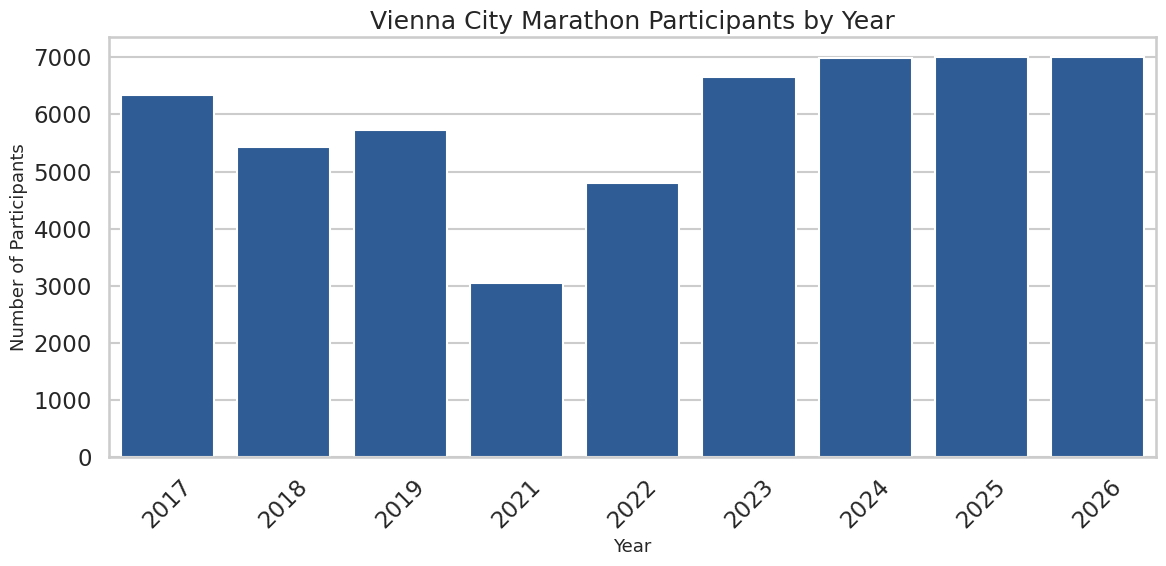

,year,participants
0,2017,6340
1,2018,5436
2,2019,5733
3,2021,3047
4,2022,4803
5,2023,6650
6,2024,6995
7,2025,7000
8,2026,7000


In [46]:
participants_per_year = (
    marathon_df.groupby("year")["participant_id"]
    .nunique()
    .reset_index(name="participants")
    .sort_values("year")
)

ax = sns.barplot(
    data=participants_per_year,
    x="year",
    y="participants",
    color="#1f5aa6",
)
ax.set_title("Vienna City Marathon Participants by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Participants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

participants_per_year

## Schnellste 50 Laufzeiten pro Jahr

Diese Darstellung eignet sich gut fuer einen qualitativen Vergleich zwischen den Jahren. Pro Jahr wird die Elite-Spitze vom schnellsten bis zum 50. schnellsten Ergebnis gezeigt.

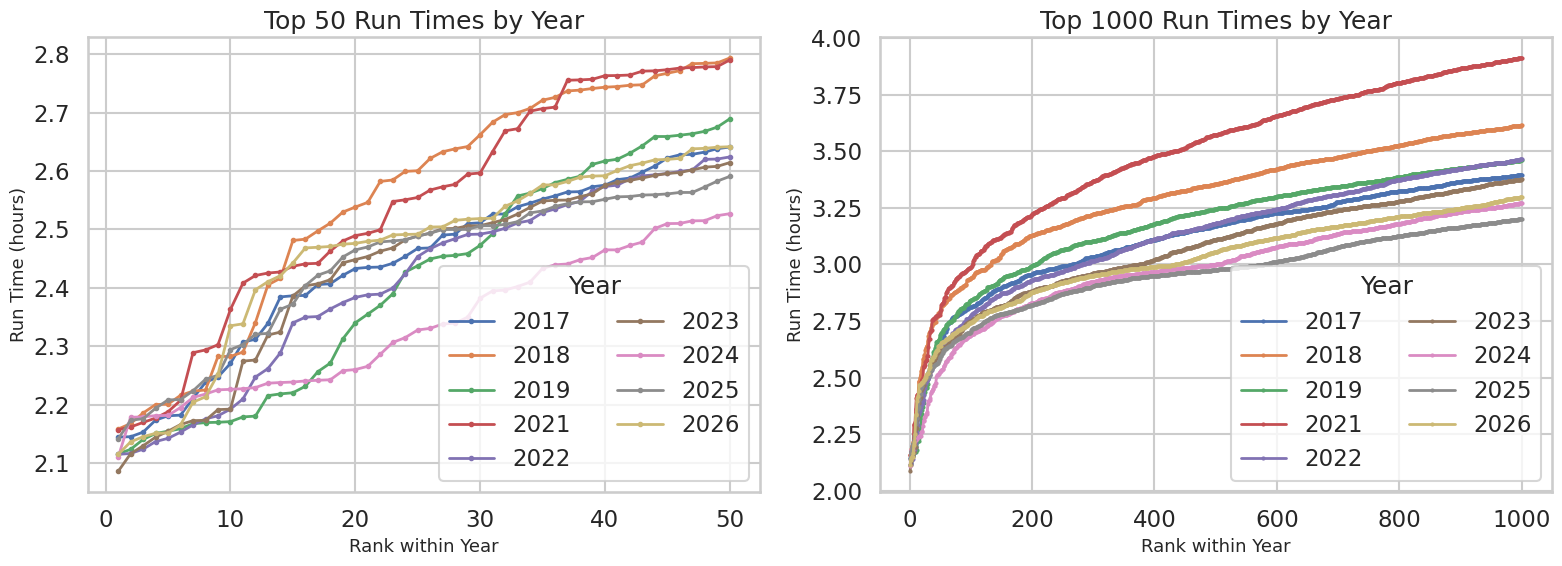

,year,avg_top_50_hours,avg_top_1000_hours
0,2017,2.442572,3.116924
1,2018,2.552578,3.300330
2,2019,2.409578,3.174321
3,2021,2.543383,3.489792
4,2022,2.409267,3.127809
5,2023,2.429778,3.063252
6,2024,2.337167,2.981446
7,2025,2.436933,2.954827
8,2026,2.463056,3.022229


In [47]:
runtime_rank_df = marathon_df[["year", "run_hours"]].copy()
runtime_rank_df = runtime_rank_df.sort_values(["year", "run_hours"]).reset_index(drop=True)
runtime_rank_df["rank_in_year"] = runtime_rank_df.groupby("year").cumcount() + 1

def average_top_n_by_year(rank_df, top_n):
    return (
        rank_df[rank_df["rank_in_year"] <= top_n]
        .groupby("year", as_index=False)["run_hours"]
        .mean()
        .rename(columns={"run_hours": f"avg_top_{top_n}_hours"})
    )

top_50_runtime_df = runtime_rank_df[runtime_rank_df["rank_in_year"] <= 50].copy()
top_1000_runtime_df = runtime_rank_df[runtime_rank_df["rank_in_year"] <= 1000].copy()
top_50_average_df = average_top_n_by_year(runtime_rank_df, 50)
top_1000_average_df = average_top_n_by_year(runtime_rank_df, 1000)
top_n_average_df = (
    top_50_average_df.merge(top_1000_average_df, on="year", how="inner")
    .sort_values("year")
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 50 auf der linken Seite
for year, year_df in top_50_runtime_df.groupby("year"):
    ax1.plot(
        year_df["rank_in_year"],
        year_df["run_hours"],
        marker="o",
        linewidth=2,
        markersize=3,
        label=str(int(year)),
    )
ax1.set_title("Top 50 Run Times by Year")
ax1.set_xlabel("Rank within Year")
ax1.set_ylabel("Run Time (hours)")
ax1.legend(title="Year", ncol=2)

# Top 1000 auf der rechten Seite
for year, year_df in top_1000_runtime_df.groupby("year"):
    ax2.plot(
        year_df["rank_in_year"],
        year_df["run_hours"],
        marker="o",
        linewidth=2,
        markersize=2,
        label=str(int(year)),
    )
ax2.set_title("Top 1000 Run Times by Year")
ax2.set_xlabel("Rank within Year")
ax2.set_ylabel("Run Time (hours)")
ax2.legend(title="Year", ncol=2)

plt.tight_layout()
plt.show()

top_n_average_df

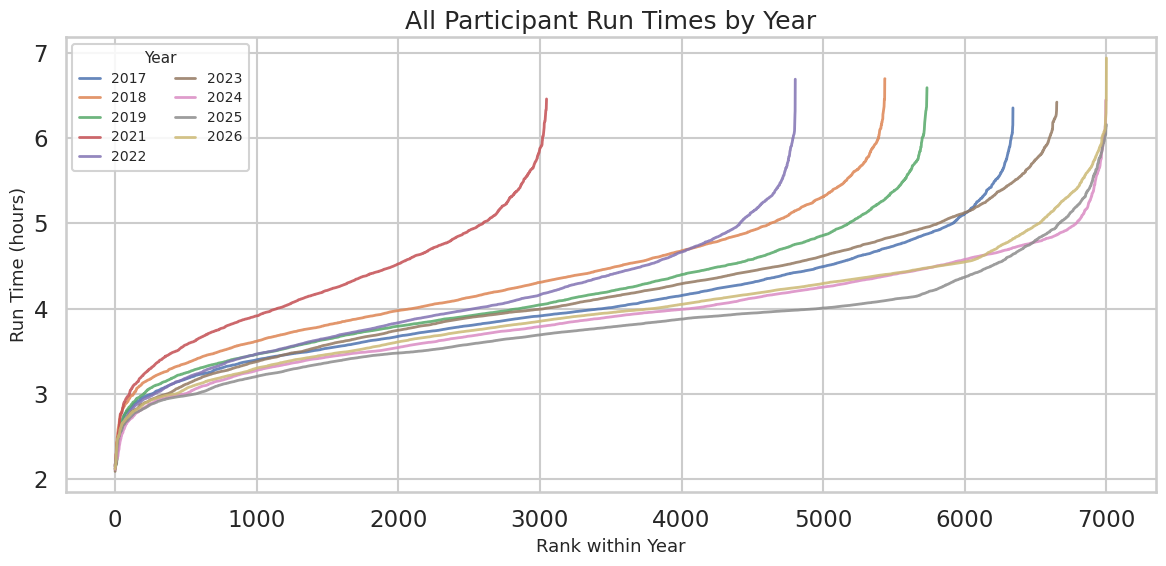

,year,avg_all_hours,participants
0,2017,4.005462,6340
1,2018,4.255623,5436
2,2019,4.082433,5733
3,2021,4.261004,3047
4,2022,4.008248,4803
5,2023,4.141333,6650
6,2024,3.910223,6995
7,2025,3.805602,7000
8,2026,3.975978,7000


In [79]:
all_runtime_df = runtime_rank_df.copy()

all_average_df = (
    runtime_rank_df.groupby("year", as_index=False)
    .agg(
        avg_all_hours=("run_hours", "mean"),
        participants=("run_hours", "size"),
    )
    .sort_values("year")
)

legend_kwargs = {
    "title": "Year",
    "ncol": 2,
    "fontsize": 10,
    "title_fontsize": 11,
    "framealpha": 0.85,
    "borderpad": 0.5,
    "labelspacing": 0.4,
    "handlelength": 1.5,
}

fig, ax = plt.subplots(figsize=(12, 6))

for year, year_df in all_runtime_df.groupby("year"):
    ax.plot(
        year_df["rank_in_year"],
        year_df["run_hours"],
        linewidth=2.0,
        alpha=0.85,
        label=str(int(year)),
    )

ax.set_title("All Participant Run Times by Year")
ax.set_xlabel("Rank within Year")
ax.set_ylabel("Run Time (hours)")
ax.legend(**legend_kwargs)

plt.tight_layout()
plt.show()

all_average_df

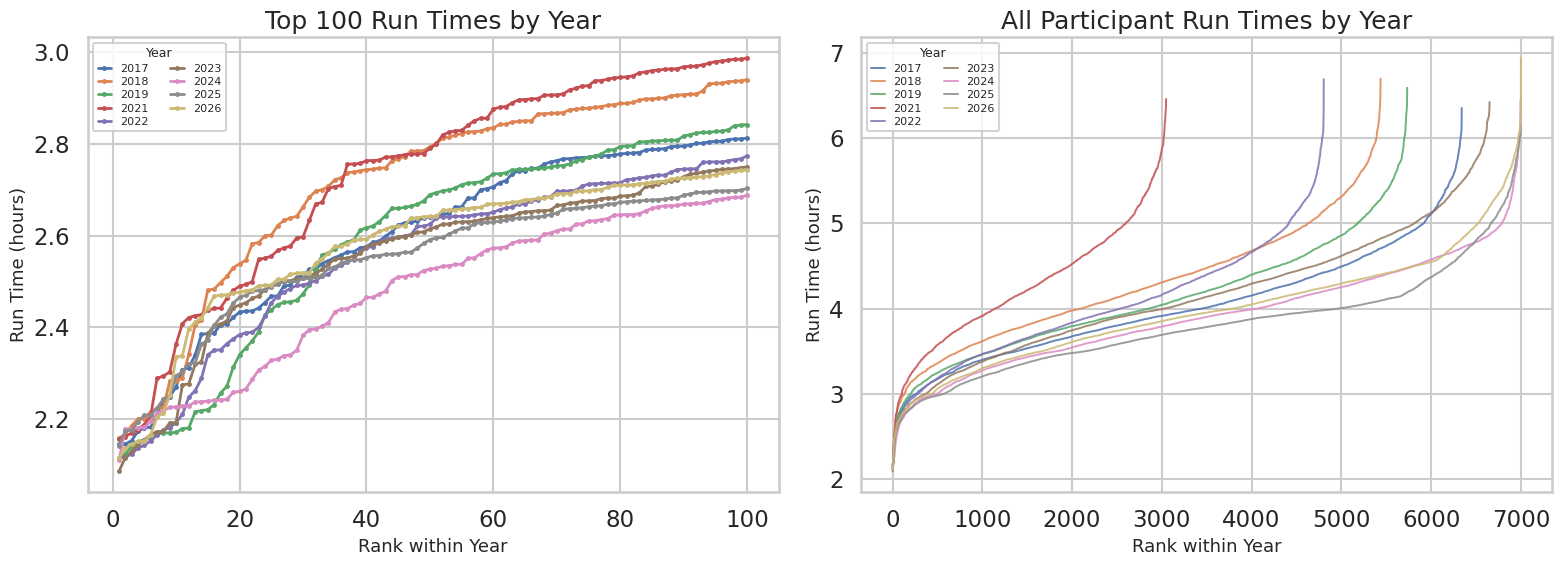

,year,avg_top_100_hours,avg_all_hours,participants
0,2017,2.599436,4.005462,6340
1,2018,2.714514,4.255623,5436
2,2019,2.591161,4.082433,5733
3,2021,2.731878,4.261004,3047
4,2022,2.556397,4.008248,4803
5,2023,2.555675,4.141333,6650
6,2024,2.479028,3.910223,6995
7,2025,2.547844,3.805602,7000
8,2026,2.580381,3.975978,7000


In [70]:
top_100_runtime_df = runtime_rank_df[runtime_rank_df["rank_in_year"] <= 100].copy()
all_runtime_df = runtime_rank_df.copy()

top_100_average_df = average_top_n_by_year(runtime_rank_df, 100)
all_average_df = (
    runtime_rank_df.groupby("year", as_index=False)
    .agg(
        avg_all_hours=("run_hours", "mean"),
        participants=("run_hours", "size"),
    )
)

top_100_all_average_df = (
    top_100_average_df.merge(all_average_df, on="year", how="inner")
    .sort_values("year")
)

legend_kwargs = {
    "title": "Year",
    "ncol": 2,
    "fontsize": 8,
    "title_fontsize": 9,
    "framealpha": 0.85,
    "borderpad": 0.4,
    "labelspacing": 0.3,
    "handlelength": 1.2,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for year, year_df in top_100_runtime_df.groupby("year"):
    ax1.plot(
        year_df["rank_in_year"],
        year_df["run_hours"],
        marker="o",
        linewidth=2,
        markersize=2.5,
        label=str(int(year)),
    )
ax1.set_title("Top 100 Run Times by Year")
ax1.set_xlabel("Rank within Year")
ax1.set_ylabel("Run Time (hours)")
ax1.legend(**legend_kwargs)

for year, year_df in all_runtime_df.groupby("year"):
    ax2.plot(
        year_df["rank_in_year"],
        year_df["run_hours"],
        linewidth=1.4,
        alpha=0.85,
        label=str(int(year)),
    )
ax2.set_title("All Participant Run Times by Year")
ax2.set_xlabel("Rank within Year")
ax2.set_ylabel("Run Time (hours)")
ax2.legend(**legend_kwargs)

plt.tight_layout()
plt.show()

top_100_all_average_df

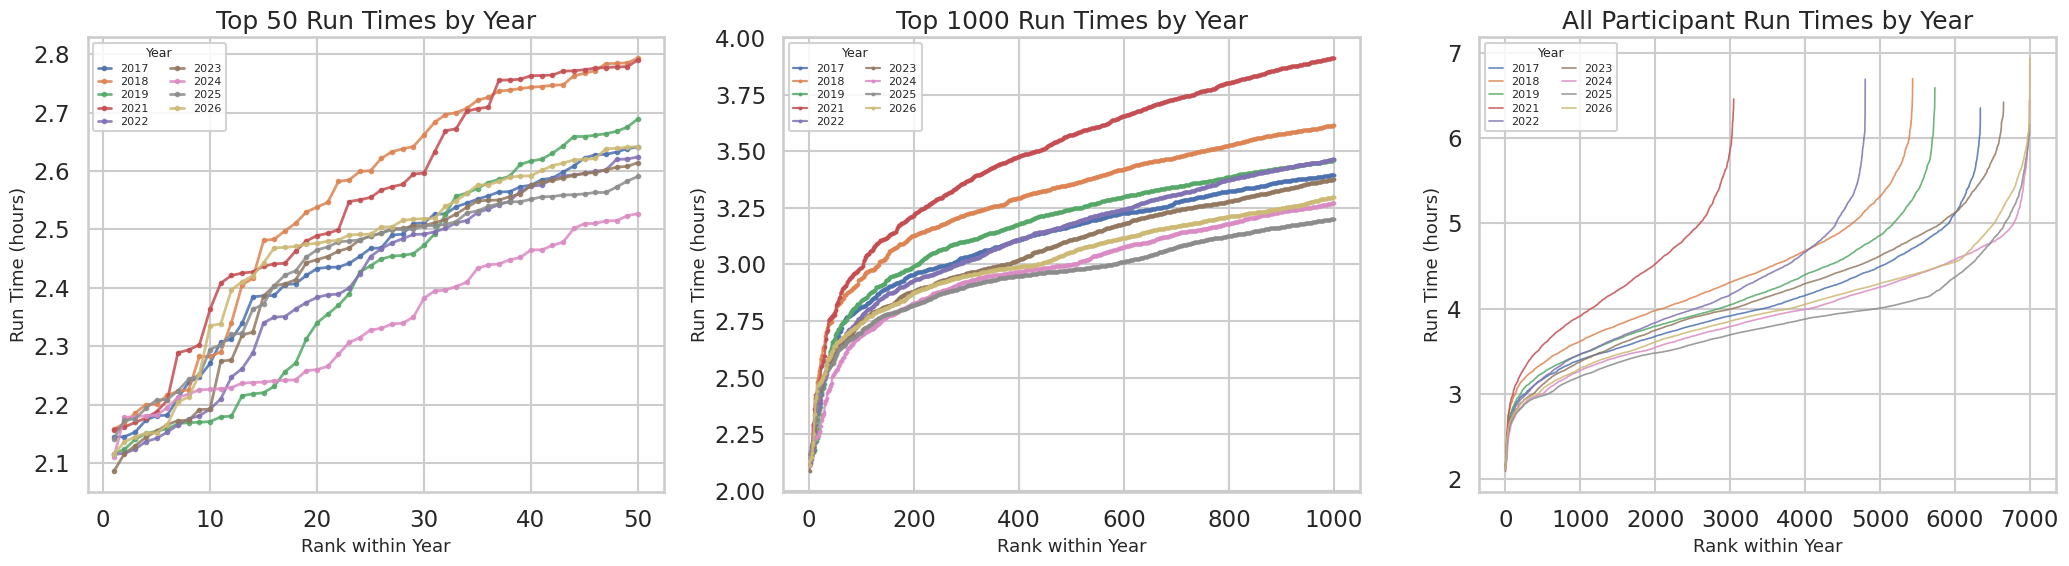

,year,avg_top_50_hours,avg_top_1000_hours,avg_all_hours,participants
0,2017,2.442572,3.116924,4.005462,6340
1,2018,2.552578,3.300330,4.255623,5436
2,2019,2.409578,3.174321,4.082433,5733
3,2021,2.543383,3.489792,4.261004,3047
4,2022,2.409267,3.127809,4.008248,4803
5,2023,2.429778,3.063252,4.141333,6650
6,2024,2.337167,2.981446,3.910223,6995
7,2025,2.436933,2.954827,3.805602,7000
8,2026,2.463056,3.022229,3.975978,7000


In [72]:
top_50_runtime_df = runtime_rank_df[runtime_rank_df["rank_in_year"] <= 50].copy()
top_1000_runtime_df = runtime_rank_df[runtime_rank_df["rank_in_year"] <= 1000].copy()
all_runtime_df = runtime_rank_df.copy()

runtime_comparison_specs = [
    ("Top 50 Run Times by Year", top_50_runtime_df, 3.0, 2.0),
    ("Top 1000 Run Times by Year", top_1000_runtime_df, 1.8, 1.6),
    ("All Participant Run Times by Year", all_runtime_df, 0, 1.2),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)

for ax, (title, plot_df, marker_size, line_width) in zip(axes, runtime_comparison_specs):
    for year, year_df in plot_df.groupby("year"):
        ax.plot(
            year_df["rank_in_year"],
            year_df["run_hours"],
            marker="o" if marker_size else None,
            linewidth=line_width,
            markersize=marker_size,
            alpha=0.85,
            label=str(int(year)),
        )

    ax.set_title(title)
    ax.set_xlabel("Rank within Year")
    ax.set_ylabel("Run Time (hours)")
    ax.legend(**legend_kwargs)

plt.tight_layout()
plt.show()

runtime_comparison_summary_df = (
    top_50_average_df
    .merge(top_1000_average_df, on="year", how="inner")
    .merge(all_average_df, on="year", how="inner")
    .sort_values("year")
)

runtime_comparison_summary_df

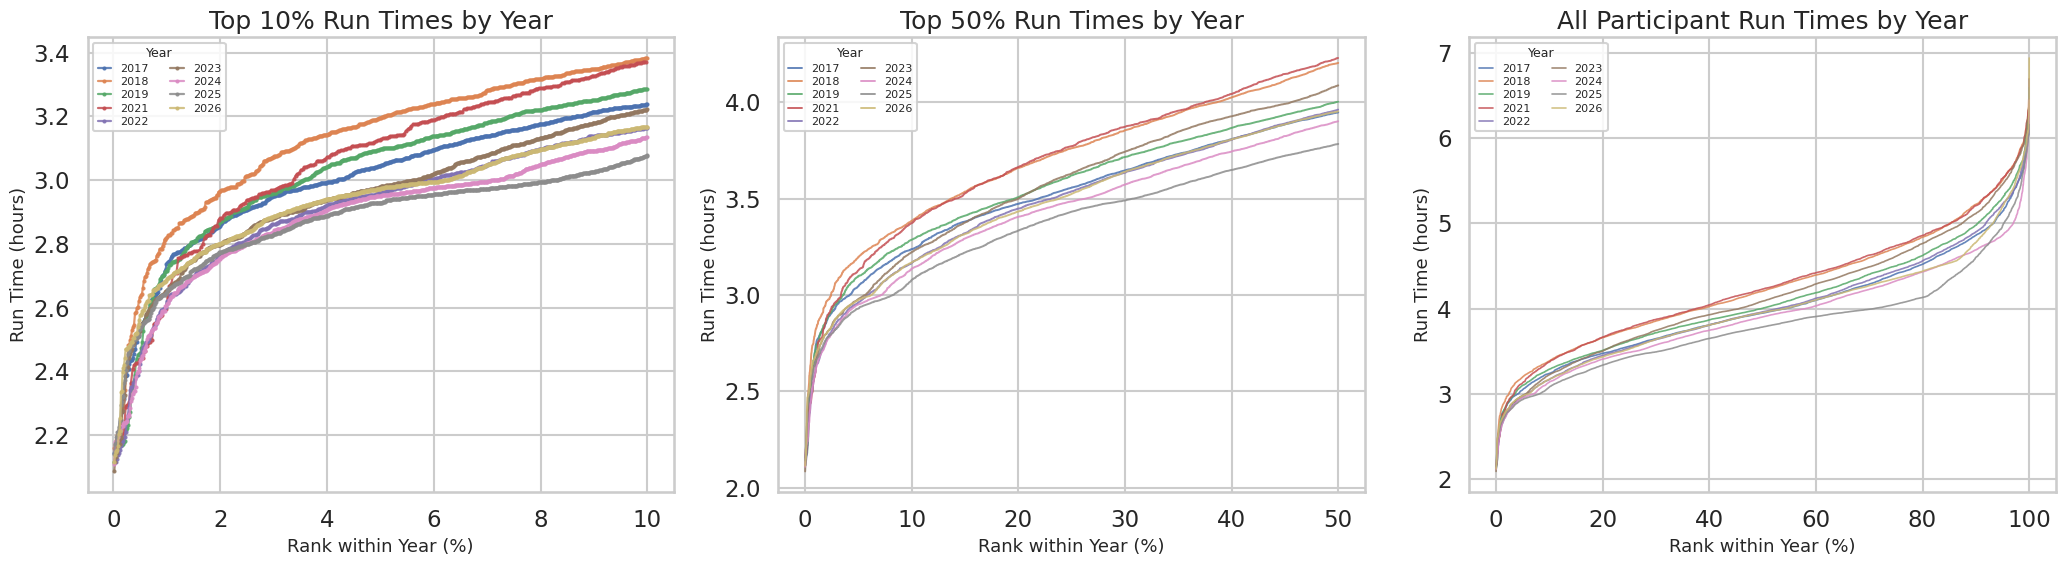

,year,avg_top_10_percent_hours,runners_top_10_percent,avg_top_50_percent_hours,runners_top_50_percent,avg_all_hours,participants
0,2017,2.996708,634,3.507314,3170,4.005462,6340
1,2018,3.123851,543,3.693213,2718,4.255623,5436
2,2019,3.022012,573,3.553625,2866,4.082433,5733
3,2021,3.054796,304,3.690148,1523,4.261004,3047
4,2022,2.909400,480,3.474831,2401,4.008248,4803
5,2023,2.944910,665,3.556408,3325,4.141333,6650
6,2024,2.885240,699,3.427223,3497,3.910223,6995
7,2025,2.873533,700,3.359740,3500,3.805602,7000
8,2026,2.933080,700,3.475985,3500,3.975978,7000


In [73]:
runtime_percentile_df = runtime_rank_df.copy()
runtime_percentile_df["participants_in_year"] = runtime_percentile_df.groupby("year")["rank_in_year"].transform("max")
runtime_percentile_df["rank_percent"] = (
    runtime_percentile_df["rank_in_year"]
    / runtime_percentile_df["participants_in_year"]
    * 100
)

top_10_percent_runtime_df = runtime_percentile_df[runtime_percentile_df["rank_percent"] <= 10].copy()
top_50_percent_runtime_df = runtime_percentile_df[runtime_percentile_df["rank_percent"] <= 50].copy()
all_percent_runtime_df = runtime_percentile_df.copy()

percentile_runtime_specs = [
    ("Top 10% Run Times by Year", top_10_percent_runtime_df, 2.0, 1.6),
    ("Top 50% Run Times by Year", top_50_percent_runtime_df, 0, 1.4),
    ("All Participant Run Times by Year", all_percent_runtime_df, 0, 1.2),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)

for ax, (title, plot_df, marker_size, line_width) in zip(axes, percentile_runtime_specs):
    for year, year_df in plot_df.groupby("year"):
        ax.plot(
            year_df["rank_percent"],
            year_df["run_hours"],
            marker="o" if marker_size else None,
            linewidth=line_width,
            markersize=marker_size,
            alpha=0.85,
            label=str(int(year)),
        )

    ax.set_title(title)
    ax.set_xlabel("Rank within Year (%)")
    ax.set_ylabel("Run Time (hours)")
    ax.legend(**legend_kwargs)

plt.tight_layout()
plt.show()

percentile_runtime_summary_df = (
    runtime_percentile_df.assign(
        top_10_percent=runtime_percentile_df["rank_percent"] <= 10,
        top_50_percent=runtime_percentile_df["rank_percent"] <= 50,
    )
    .groupby("year")
    .agg(
        avg_top_10_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 10].mean()),
        runners_top_10_percent=("top_10_percent", "sum"),
        avg_top_50_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 50].mean()),
        runners_top_50_percent=("top_50_percent", "sum"),
        avg_all_hours=("run_hours", "mean"),
        participants=("run_hours", "size"),
    )
    .reset_index()
    .sort_values("year")
)

percentile_runtime_summary_df

In [92]:
from IPython.display import HTML, display

best_runtime_years_df = (
    runtime_percentile_df.assign(
        top_1_percent=runtime_percentile_df["rank_percent"] <= 1,
        top_25_percent=runtime_percentile_df["rank_percent"] <= 25,
    )
    .groupby("year")
    .agg(
        top_1_percent_avg_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 1].mean()),
        top_25_percent_avg_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 25].mean()),
        all_participants_avg_hours=("run_hours", "mean"),
        participants=("run_hours", "size"),
    )
    .reset_index()
)

best_runtime_tables = {
    "Top 1%": "top_1_percent_avg_hours",
    "Top 25%": "top_25_percent_avg_hours",
    "All participants": "all_participants_avg_hours",
}

def make_best_year_table(metric):
    return (
        best_runtime_years_df[["year", metric, "participants"]]
        .rename(columns={metric: "avg runtime (h)", "year": "year", "participants": "participants"})
        .sort_values("avg runtime (h)")
        .assign(
            rank=lambda data: range(1, len(data) + 1),
            **{"avg runtime (h)": lambda data: data["avg runtime (h)"].round(3)},
        )
        [["rank", "year", "avg runtime (h)", "participants"]]
    )

html_tables = []
for group_name, metric in best_runtime_tables.items():
    table_html = make_best_year_table(metric).to_html(index=False, classes="runtime-ranking-table")
    html_tables.append(
        f"""
        <div class="runtime-ranking-card">
            <h3>{group_name}</h3>
            {table_html}
        </div>
        """
    )

display(HTML(
    f"""
    <style>
        .runtime-ranking-wrap {{
            display: flex;
            gap: 18px;
            align-items: flex-start;
        }}
        .runtime-ranking-card {{
            flex: 1;
            min-width: 0;
        }}
        .runtime-ranking-card h3 {{
            margin: 0 0 8px 0;
            font-size: 18px;
            text-align: center;
        }}
        .runtime-ranking-table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 13px;
        }}
        .runtime-ranking-table th,
        .runtime-ranking-table td {{
            border: 1px solid #d0d0d0;
            padding: 5px 7px;
            text-align: right;
        }}
        .runtime-ranking-table th {{
            background: #f2f2f2;
        }}
        .runtime-ranking-table td:nth-child(2),
        .runtime-ranking-table th:nth-child(2) {{
            text-align: center;
        }}
    </style>
    <div class="runtime-ranking-wrap">
        {''.join(html_tables)}
    </div>
    """
))

rank,year,avg runtime (h),participants
1,2022,2.400,4803
2,2024,2.400,6995
3,2021,2.410,3047
4,2019,2.446,5733
5,2023,2.480,6650
6,2025,2.491,7000
7,2017,2.493,6340
8,2026,2.522,7000
9,2018,2.572,5436
rank,year,avg runtime (h),participants


In [95]:
summary_runtime_df = (
    runtime_percentile_df.assign(
        top_1_percent=runtime_percentile_df["rank_percent"] <= 1,
        top_25_percent=runtime_percentile_df["rank_percent"] <= 25,
    )
    .groupby("year")
    .agg(
        top_1_percent_avg_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 1].mean()),
        top_25_percent_avg_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 25].mean()),
        all_participants_avg_hours=("run_hours", "mean"),
        participants=("run_hours", "size"),
    )
    .reset_index()
)

summary_specs = [
    ("Top 1%", "top_1_percent_avg_hours"),
    ("Top 25%", "top_25_percent_avg_hours"),
    ("All", "all_participants_avg_hours"),
]

summary_rows = []
for group, metric in summary_specs:
    best_row = summary_runtime_df.loc[summary_runtime_df[metric].idxmin()]
    worst_row = summary_runtime_df.loc[summary_runtime_df[metric].idxmax()]

    summary_rows.extend([
        {
            "group": group,
            "type": "Best year",
            "year": int(best_row["year"]),
            "avg_hours": round(best_row[metric], 3),
            "participants": int(best_row["participants"]),
        },
        {
            "group": group,
            "type": "Worst year",
            "year": int(worst_row["year"]),
            "avg_hours": round(worst_row[metric], 3),
            "participants": int(worst_row["participants"]),
        },
    ])

runtime_best_worst_years_df = pd.DataFrame(summary_rows)
runtime_best_worst_years_df

,group,type,year,avg_hours,participants
0,Top 1%,Best year,2022,2.400,4803
1,Top 1%,Worst year,2018,2.572,5436
2,Top 25%,Best year,2025,3.112,7000
3,Top 25%,Worst year,2018,3.404,5436
4,All,Best year,2025,3.806,7000
5,All,Worst year,2021,4.261,3047


In [97]:
def hours_to_hms(hours):
    total_seconds = int(round(hours * 3600))
    h = total_seconds // 3600
    m = (total_seconds % 3600) // 60
    s = total_seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

fastest_runtimes_df = (
    runtime_percentile_df[["year", "run_hours"]]
    .sort_values("run_hours")
    .head(3)
    .assign(
        rank=lambda data: range(1, len(data) + 1),
        runtime=lambda data: data["run_hours"].apply(hours_to_hms),
        runtime_hours=lambda data: data["run_hours"].round(3),
        year=lambda data: data["year"].astype(int),
    )
    [["rank", "year", "runtime", "runtime_hours"]]
)

slowest_runtimes_df = (
    runtime_percentile_df[["year", "run_hours"]]
    .sort_values("run_hours", ascending=False)
    .head(3)
    .assign(
        rank=lambda data: range(1, len(data) + 1),
        runtime=lambda data: data["run_hours"].apply(hours_to_hms),
        runtime_hours=lambda data: data["run_hours"].round(3),
        year=lambda data: data["year"].astype(int),
    )
    [["rank", "year", "runtime", "runtime_hours"]]
)

fastest_table_html = fastest_runtimes_df.to_html(index=False, classes="runtime-extreme-table")
slowest_table_html = slowest_runtimes_df.to_html(index=False, classes="runtime-extreme-table")

display(HTML(
    f"""
    <style>
        .runtime-extreme-wrap {{
            display: flex;
            gap: 24px;
            align-items: flex-start;
        }}
        .runtime-extreme-card {{
            flex: 1;
            min-width: 0;
        }}
        .runtime-extreme-card h3 {{
            margin: 0 0 8px 0;
            font-size: 18px;
            text-align: center;
        }}
        .runtime-extreme-table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 13px;
        }}
        .runtime-extreme-table th,
        .runtime-extreme-table td {{
            border: 1px solid #d0d0d0;
            padding: 6px 8px;
            text-align: right;
        }}
        .runtime-extreme-table th {{
            background: #f2f2f2;
        }}
        .runtime-extreme-table td:nth-child(2),
        .runtime-extreme-table th:nth-child(2),
        .runtime-extreme-table td:nth-child(3),
        .runtime-extreme-table th:nth-child(3) {{
            text-align: center;
        }}
    </style>
    <div class="runtime-extreme-wrap">
        <div class="runtime-extreme-card">
            <h3>Fastest runtimes</h3>
            {fastest_table_html}
        </div>
        <div class="runtime-extreme-card">
            <h3>Slowest runtimes</h3>
            {slowest_table_html}
        </div>
    </div>
    """
))

rank,year,runtime,runtime_hours
1,2023,02:05:08,2.086
2,2024,02:06:35,2.110
3,2026,02:06:53,2.115
rank,year,runtime,runtime_hours
1,2026,06:56:38,6.944
2,2018,06:42:03,6.701
3,2018,06:42:03,6.701


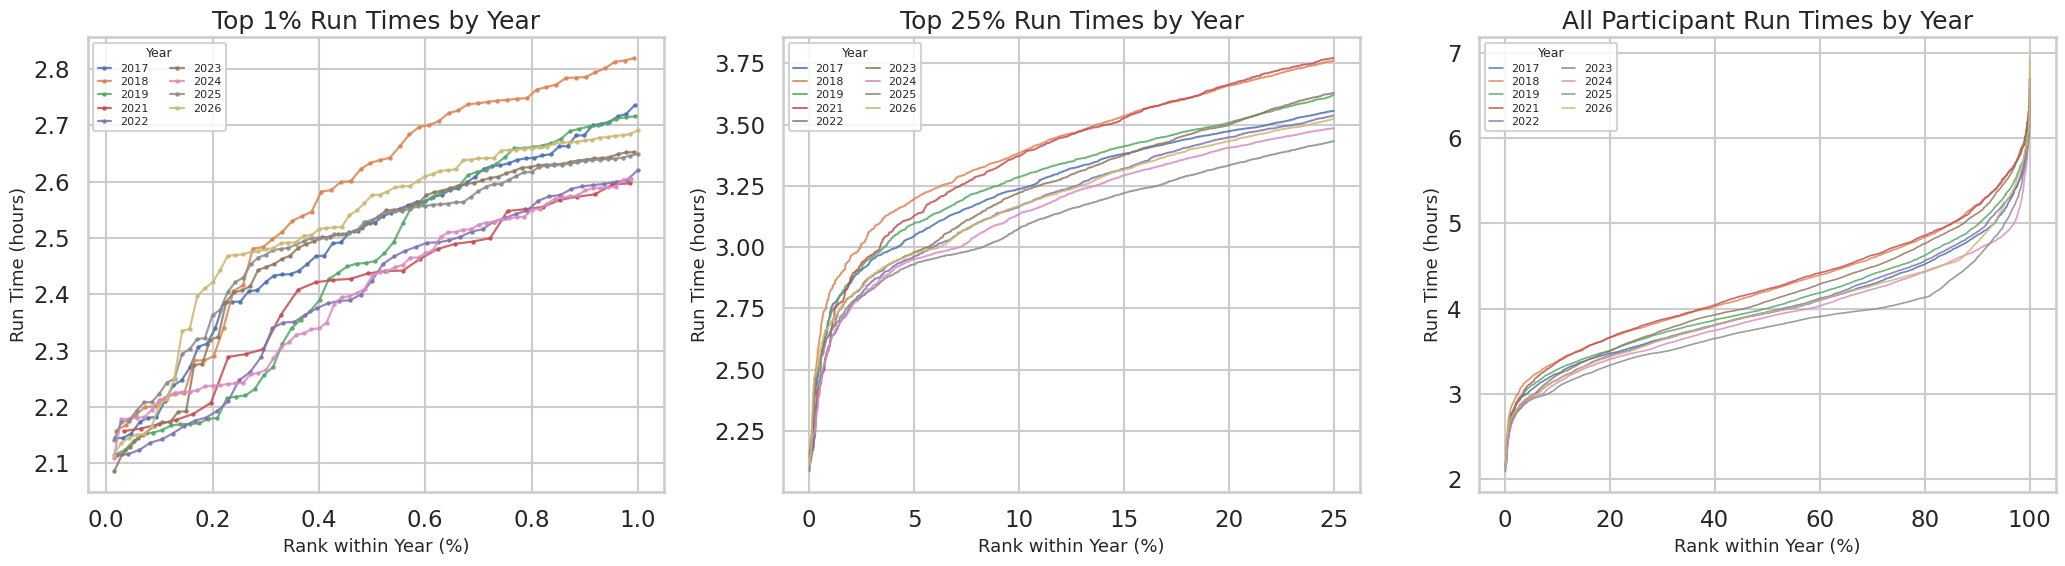

,year,avg_top_1_percent_hours,runners_top_1_percent,avg_top_25_percent_hours,runners_top_25_percent,avg_all_hours,participants
0,2017,2.492588,63,3.250160,1585,4.005462,6340
1,2018,2.571785,54,3.403930,1359,4.255623,5436
2,2019,2.445858,57,3.284016,1433,4.082433,5733
3,2021,2.409926,30,3.376820,761,4.261004,3047
4,2022,2.400388,48,3.189625,1200,4.008248,4803
5,2023,2.479802,66,3.239861,1662,4.141333,6650
6,2024,2.400439,69,3.156449,1748,3.910223,6995
7,2025,2.491325,70,3.112441,1750,3.805602,7000
8,2026,2.521730,70,3.192894,1750,3.975978,7000


In [76]:
top_1_percent_runtime_df = runtime_percentile_df[runtime_percentile_df["rank_percent"] <= 1].copy()
top_25_percent_runtime_df = runtime_percentile_df[runtime_percentile_df["rank_percent"] <= 25].copy()
all_percent_runtime_df = runtime_percentile_df.copy()

percentile_runtime_specs = [
    ("Top 1% Run Times by Year", top_1_percent_runtime_df, 2.2, 1.6),
    ("Top 25% Run Times by Year", top_25_percent_runtime_df, 0, 1.4),
    ("All Participant Run Times by Year", all_percent_runtime_df, 0, 1.2),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)

for ax, (title, plot_df, marker_size, line_width) in zip(axes, percentile_runtime_specs):
    for year, year_df in plot_df.groupby("year"):
        ax.plot(
            year_df["rank_percent"],
            year_df["run_hours"],
            marker="o" if marker_size else None,
            linewidth=line_width,
            markersize=marker_size,
            alpha=0.85,
            label=str(int(year)),
        )

    ax.set_title(title)
    ax.set_xlabel("Rank within Year (%)")
    ax.set_ylabel("Run Time (hours)")
    ax.legend(**legend_kwargs)

plt.tight_layout()
plt.show()

percentile_runtime_1_25_summary_df = (
    runtime_percentile_df.assign(
        top_1_percent=runtime_percentile_df["rank_percent"] <= 1,
        top_25_percent=runtime_percentile_df["rank_percent"] <= 25,
    )
    .groupby("year")
    .agg(
        avg_top_1_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 1].mean()),
        runners_top_1_percent=("top_1_percent", "sum"),
        avg_top_25_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 25].mean()),
        runners_top_25_percent=("top_25_percent", "sum"),
        avg_all_hours=("run_hours", "mean"),
        participants=("run_hours", "size"),
    )
    .reset_index()
    .sort_values("year")
)

percentile_runtime_1_25_summary_df

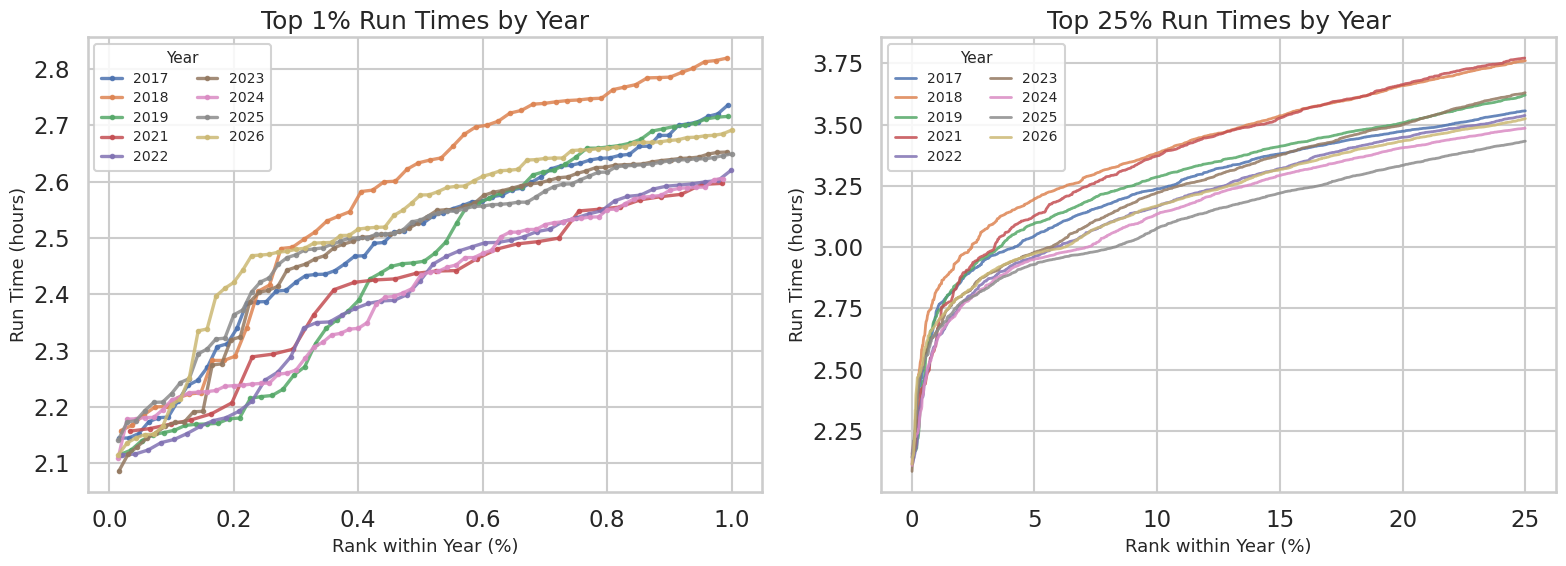

,year,avg_top_1_percent_hours,runners_top_1_percent,avg_top_25_percent_hours,runners_top_25_percent,participants
0,2017,2.492588,63,3.250160,1585,6340
1,2018,2.571785,54,3.403930,1359,5436
2,2019,2.445858,57,3.284016,1433,5733
3,2021,2.409926,30,3.376820,761,3047
4,2022,2.400388,48,3.189625,1200,4803
5,2023,2.479802,66,3.239861,1662,6650
6,2024,2.400439,69,3.156449,1748,6995
7,2025,2.491325,70,3.112441,1750,7000
8,2026,2.521730,70,3.192894,1750,7000


In [84]:
top_1_percent_runtime_df = runtime_percentile_df[runtime_percentile_df["rank_percent"] <= 1].copy()
top_25_percent_runtime_df = runtime_percentile_df[runtime_percentile_df["rank_percent"] <= 25].copy()

percentile_runtime_two_panel_specs = [
    ("Top 1% Run Times by Year", top_1_percent_runtime_df, 3.0, 2.4),
    ("Top 25% Run Times by Year", top_25_percent_runtime_df, 0, 2.0),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, (title, plot_df, marker_size, line_width) in zip(axes, percentile_runtime_two_panel_specs):
    for year, year_df in plot_df.groupby("year"):
        ax.plot(
            year_df["rank_percent"],
            year_df["run_hours"],
            marker="o" if marker_size else None,
            linewidth=line_width,
            markersize=marker_size,
            alpha=0.85,
            label=str(int(year)),
        )

    ax.set_title(title)
    ax.set_xlabel("Rank within Year (%)")
    ax.set_ylabel("Run Time (hours)")
    ax.legend(**legend_kwargs)

plt.tight_layout()
plt.show()

percentile_runtime_1_25_two_panel_summary_df = (
    runtime_percentile_df.assign(
        top_1_percent=runtime_percentile_df["rank_percent"] <= 1,
        top_25_percent=runtime_percentile_df["rank_percent"] <= 25,
    )
    .groupby("year")
    .agg(
        avg_top_1_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 1].mean()),
        runners_top_1_percent=("top_1_percent", "sum"),
        avg_top_25_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 25].mean()),
        runners_top_25_percent=("top_25_percent", "sum"),
        participants=("run_hours", "size"),
    )
    .reset_index()
    .sort_values("year")
)

percentile_runtime_1_25_two_panel_summary_df

## 3. Temperatur im Marathon-Monat

Die Wetterdatei enthaelt Monatswerte. Deshalb verwenden wir hier den April als beste Naeherung fuer die Bedingungen rund um den Vienna City Marathon und zeigen die Durchschnittstemperatur pro Jahr als Balkendiagramm.

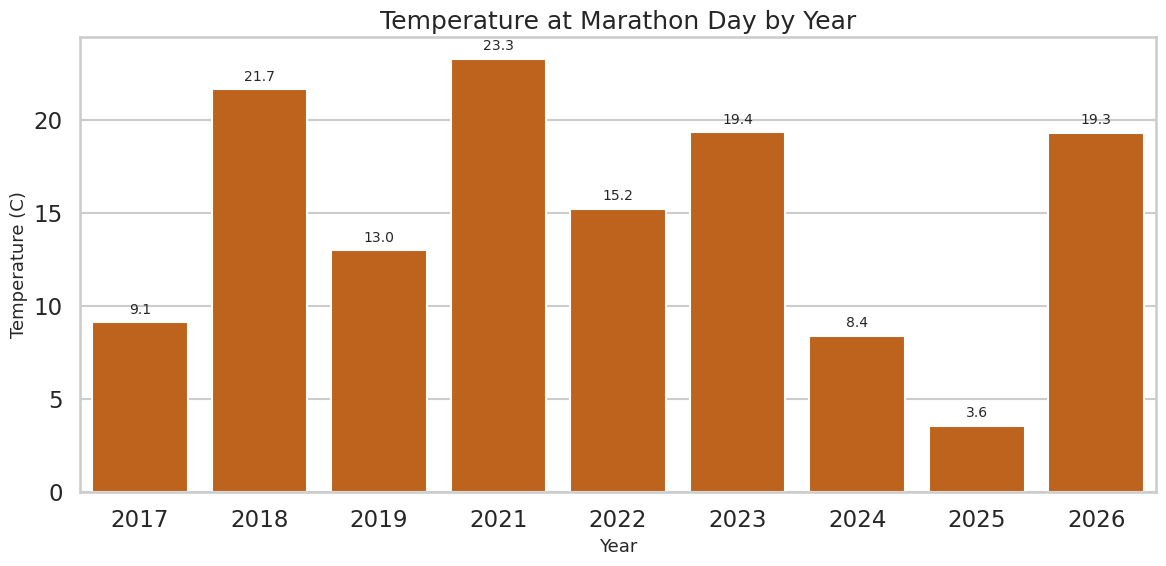

,year,temperature_c,precipitation_mm,humidity,wind_kph
0,2017,9.13,0,50,25.2
1,2018,21.66,0,50,14.4
2,2019,13.00,0,68,27.4
3,2021,23.30,0,65,4.8
4,2022,15.24,0,68,32.2
5,2023,19.36,0,54,4.8
6,2024,8.41,0,58,25.7
7,2025,3.56,0,46,40.2
8,2026,19.34,0,50,1.6


In [48]:
marathon_weather_df = (
    weather_df[["year", "temp_c", "rain_mm", "humidity", "wind_kph"]]
    .rename(columns={"year": "year", "temp_c": "temperature_c", "rain_mm": "precipitation_mm"})
    .dropna(subset=["year", "temperature_c"])
    .sort_values("year")
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=marathon_weather_df,
    x="year",
    y="temperature_c",
    color="#d95f02",
)

ax.set_title("Temperature at Marathon Day by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (C)")

for patch, value in zip(ax.patches, marathon_weather_df["temperature_c"]):
    ax.annotate(
        f"{value:.1f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

marathon_weather_df

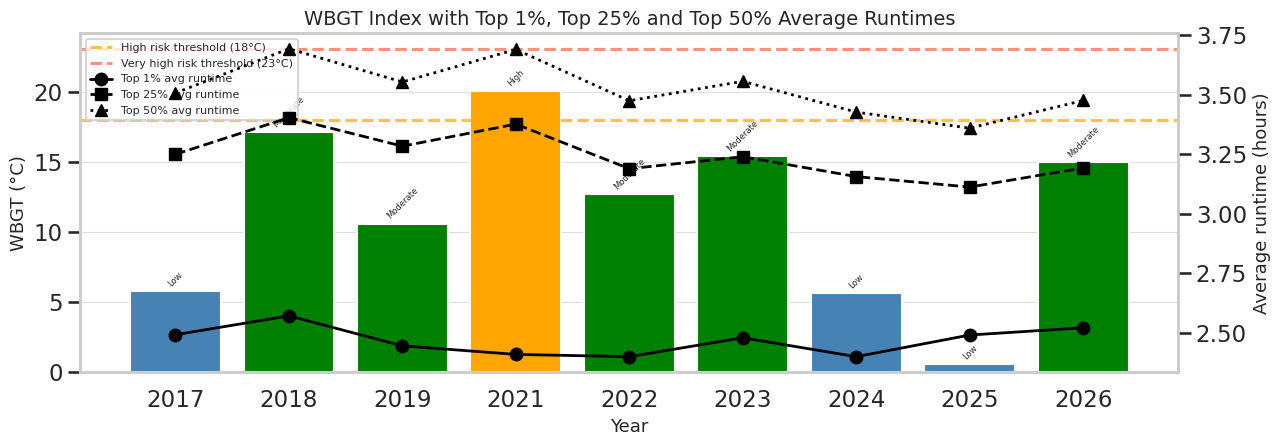

,year,wbgt,risk,avg_top_1_percent_hours,avg_top_25_percent_hours,avg_top_50_percent_hours
0,2017,5.786228,Low,2.492588,3.250160,3.507314
1,2018,17.086592,Moderate,2.571785,3.403930,3.693213
2,2019,10.585406,Moderate,2.445858,3.284016,3.553625
3,2021,20.059292,High,2.409926,3.376820,3.690148
4,2022,12.708413,Moderate,2.400388,3.189625,3.474831
5,2023,15.376433,Moderate,2.479802,3.239861,3.556408
6,2024,5.617389,Low,2.400439,3.156449,3.427223
7,2025,0.585681,Low,2.491325,3.112441,3.359740
8,2026,14.994323,Moderate,2.521730,3.192894,3.475985


In [82]:
def wet_bulb(T, rh):
    return (T * np.arctan(0.151977 * (rh + 8.313659)**0.5)
            + np.arctan(T + rh)
            - np.arctan(rh - 1.676331)
            + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh)
            - 4.686035)

wbgt_runtime_percentile_df = (
    runtime_percentile_df.assign(
        top_1_percent=runtime_percentile_df["rank_percent"] <= 1,
        top_25_percent=runtime_percentile_df["rank_percent"] <= 25,
        top_50_percent=runtime_percentile_df["rank_percent"] <= 50,
    )
    .groupby("year")
    .agg(
        avg_top_1_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 1].mean()),
        avg_top_25_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 25].mean()),
        avg_top_50_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 50].mean()),
    )
    .reset_index()
)

wbgt_performance_df = marathon_weather_df.merge(wbgt_runtime_percentile_df, on="year", how="inner").copy()
wbgt_performance_df["wet_bulb"] = wet_bulb(
    wbgt_performance_df["temperature_c"],
    wbgt_performance_df["humidity"],
)
wbgt_performance_df["wbgt"] = 0.7 * wbgt_performance_df["wet_bulb"] + 0.3 * wbgt_performance_df["temperature_c"]

def wbgt_risk(w):
    if w < 10:
        return "Low"
    elif w < 18:
        return "Moderate"
    elif w < 23:
        return "High"
    elif w < 28:
        return "Very High"
    else:
        return "Extreme"

wbgt_performance_df["risk"] = wbgt_performance_df["wbgt"].apply(wbgt_risk)

color_map = {
    "Low": "steelblue",
    "Moderate": "green",
    "High": "orange",
    "Very High": "red",
    "Extreme": "darkred",
}
colors = wbgt_performance_df["risk"].map(color_map)

year_labels = wbgt_performance_df["year"].astype(int).astype(str)
x_positions = np.arange(len(wbgt_performance_df))

fig, ax = plt.subplots(figsize=(13, 4.8))
bars = ax.bar(x_positions, wbgt_performance_df["wbgt"], color=colors)
ax.axhline(18, linestyle="--", color="orange", alpha=0.7, label="High risk threshold (18°C)")
ax.axhline(23, linestyle="--", color="tomato", alpha=0.7, label="Very high risk threshold (23°C)")
ax.set_title("WBGT Index with Top 1%, Top 25% and Top 50% Average Runtimes", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("WBGT (°C)")
ax.set_xticks(x_positions)
ax.set_xticklabels(year_labels)
ax.set_axisbelow(True)
ax.grid(axis="y", color="#d0d0d0", linewidth=0.8, alpha=0.7)
ax.grid(axis="x", visible=False)

for bar, risk in zip(bars, wbgt_performance_df["risk"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        risk,
        ha="center",
        va="bottom",
        fontsize=6,
        rotation=45,
    )

ax2 = ax.twinx()
ax2.grid(False)
ax2.plot(
    x_positions,
    wbgt_performance_df["avg_top_1_percent_hours"],
    color="black",
    marker="o",
    linewidth=2,
    label="Top 1% avg runtime",
)
ax2.plot(
    x_positions,
    wbgt_performance_df["avg_top_25_percent_hours"],
    color="black",
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Top 25% avg runtime",
)
ax2.plot(
    x_positions,
    wbgt_performance_df["avg_top_50_percent_hours"],
    color="black",
    marker="^",
    linestyle=":",
    linewidth=2,
    label="Top 50% avg runtime",
)
ax2.set_ylabel("Average runtime (hours)")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

wbgt_performance_df[["year", "wbgt", "risk", "avg_top_1_percent_hours", "avg_top_25_percent_hours", "avg_top_50_percent_hours"]]

## 4. Temperatur: Top 50 vs. Top 1000

Hier wird bewusst die Elite mit einer deutlich breiteren Leistungsgruppe verglichen. Wenn Temperatur fuer normale schnelle Laeufer wichtiger ist als fuer die absolute Spitze, sollte sich das im rechten Plot klarer zeigen als im linken.

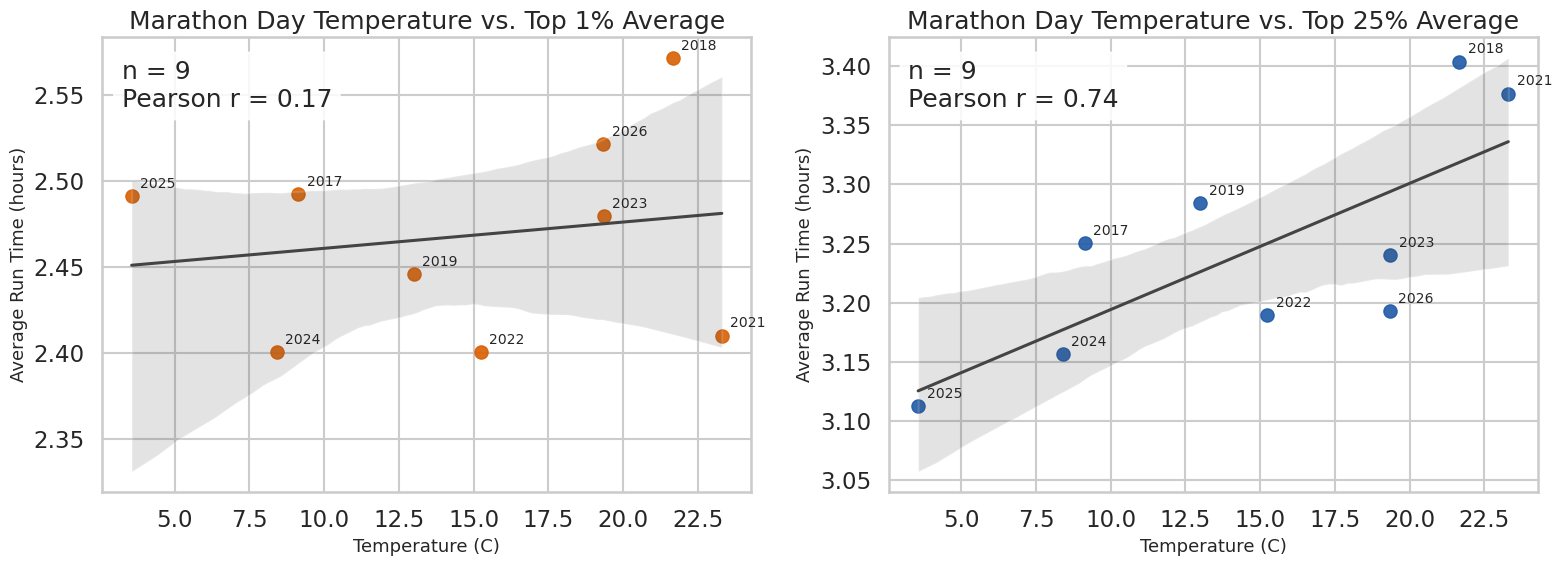

(   year  temperature_c  precipitation_mm  humidity  wind_kph  \
 0  2017           9.13                 0        50      25.2   
 1  2018          21.66                 0        50      14.4   
 2  2019          13.00                 0        68      27.4   
 3  2021          23.30                 0        65       4.8   
 4  2022          15.24                 0        68      32.2   
 5  2023          19.36                 0        54       4.8   
 6  2024           8.41                 0        58      25.7   
 7  2025           3.56                 0        46      40.2   
 8  2026          19.34                 0        50       1.6   
 
    avg_top_1_percent_hours  avg_top_25_percent_hours  
 0                 2.492588                  3.250160  
 1                 2.571785                  3.403930  
 2                 2.445858                  3.284016  
 3                 2.409926                  3.376820  
 4                 2.400388                  3.189625  
 5          

In [85]:
temperature_runtime_percentile_df = (
    runtime_percentile_df.assign(
        top_1_percent=runtime_percentile_df["rank_percent"] <= 1,
        top_25_percent=runtime_percentile_df["rank_percent"] <= 25,
    )
    .groupby("year")
    .agg(
        avg_top_1_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 1].mean()),
        avg_top_25_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 25].mean()),
    )
    .reset_index()
)

performance_vs_temperature_df = (
    marathon_weather_df.merge(temperature_runtime_percentile_df, on="year", how="inner")
    .sort_values("year")
)

temperature_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 1%",
            "observations": len(performance_vs_temperature_df),
            "pearson_correlation": performance_vs_temperature_df["temperature_c"].corr(
                performance_vs_temperature_df["avg_top_1_percent_hours"]
            ),
        },
        {
            "group": "Top 25%",
            "observations": len(performance_vs_temperature_df),
            "pearson_correlation": performance_vs_temperature_df["temperature_c"].corr(
                performance_vs_temperature_df["avg_top_25_percent_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_1_percent_hours", "Top 1%", "#d95f02"),
    (ax2, "avg_top_25_percent_hours", "Top 25%", "#1f5aa6"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=performance_vs_temperature_df,
        x="temperature_c",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in performance_vs_temperature_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["temperature_c"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = temperature_correlation_table.loc[
        temperature_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"Marathon Day Temperature vs. {label} Average")
    ax.set_xlabel("Temperature (C)")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(performance_vs_temperature_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

performance_vs_temperature_df, temperature_correlation_table

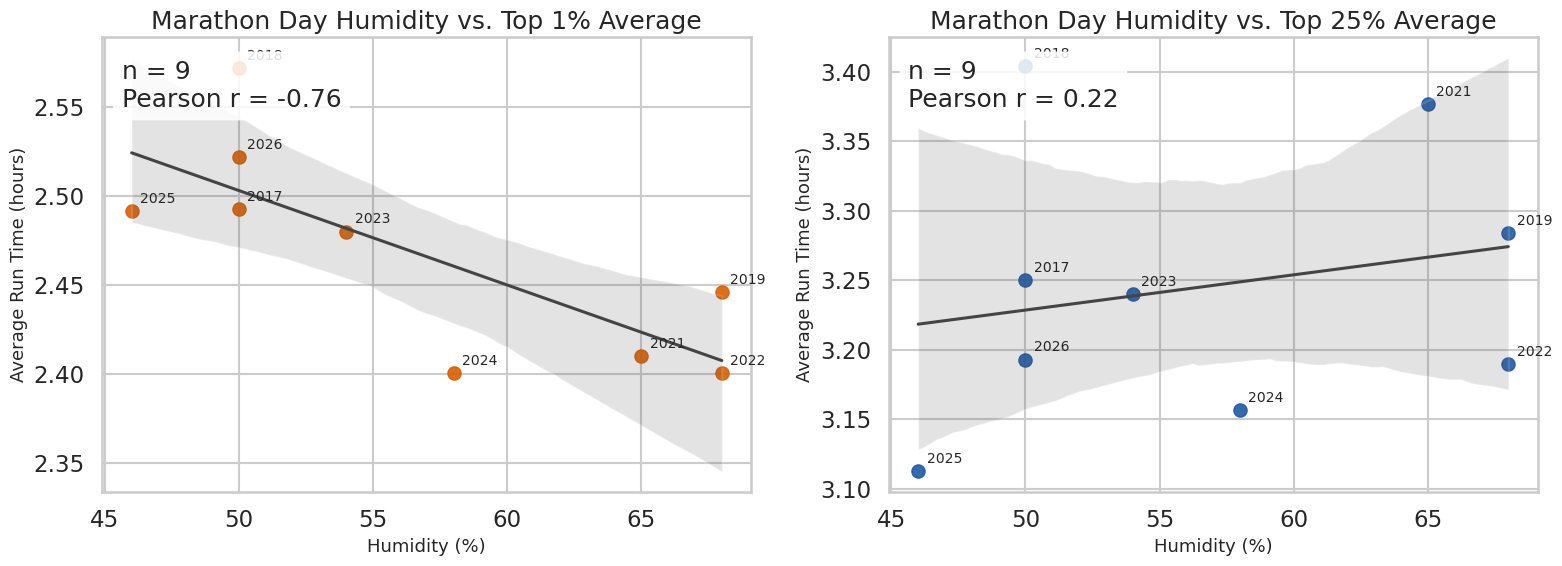

(   year  temperature_c  precipitation_mm  humidity  wind_kph  \
 0  2017           9.13                 0        50      25.2   
 1  2018          21.66                 0        50      14.4   
 2  2019          13.00                 0        68      27.4   
 3  2021          23.30                 0        65       4.8   
 4  2022          15.24                 0        68      32.2   
 5  2023          19.36                 0        54       4.8   
 6  2024           8.41                 0        58      25.7   
 7  2025           3.56                 0        46      40.2   
 8  2026          19.34                 0        50       1.6   
 
    avg_top_1_percent_hours  avg_top_25_percent_hours  
 0                 2.492588                  3.250160  
 1                 2.571785                  3.403930  
 2                 2.445858                  3.284016  
 3                 2.409926                  3.376820  
 4                 2.400388                  3.189625  
 5          

In [ ]:
performance_vs_humidity_df = (
    marathon_weather_df.merge(humidity_runtime_percentile_df, on="year", how="inner")
    .sort_values("year")
)

humidity_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 1%",
            "observations": len(performance_vs_humidity_df),
            "pearson_correlation": performance_vs_humidity_df["humidity"].corr(
                performance_vs_humidity_df["avg_top_1_percent_hours"]
            ),
        },
        {
            "group": "Top 25%",
            "observations": len(performance_vs_humidity_df),
            "pearson_correlation": performance_vs_humidity_df["humidity"].corr(
                performance_vs_humidity_df["avg_top_25_percent_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_1_percent_hours", "Top 1%", "#d95f02"),
    (ax2, "avg_top_25_percent_hours", "Top 25%", "#1f5aa6"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=performance_vs_humidity_df,
        x="humidity",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in performance_vs_humidity_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["humidity"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = humidity_correlation_table.loc[
        humidity_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"Marathon Day Humidity vs. {label} Average")
    ax.set_xlabel("Humidity (%)")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(performance_vs_humidity_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

performance_vs_humidity_df, humidity_correlation_table

## 5. Luftqualitaets-Trends

Die Luftqualitaetsdaten ergaenzen die Praesentation um einen zweiten staedtischen Kontext. Fuer die Folien sind vor allem PM10, PM2.5 und NO2 gute Kandidaten, weil sie gut bekannt und leicht erklaerbar sind.

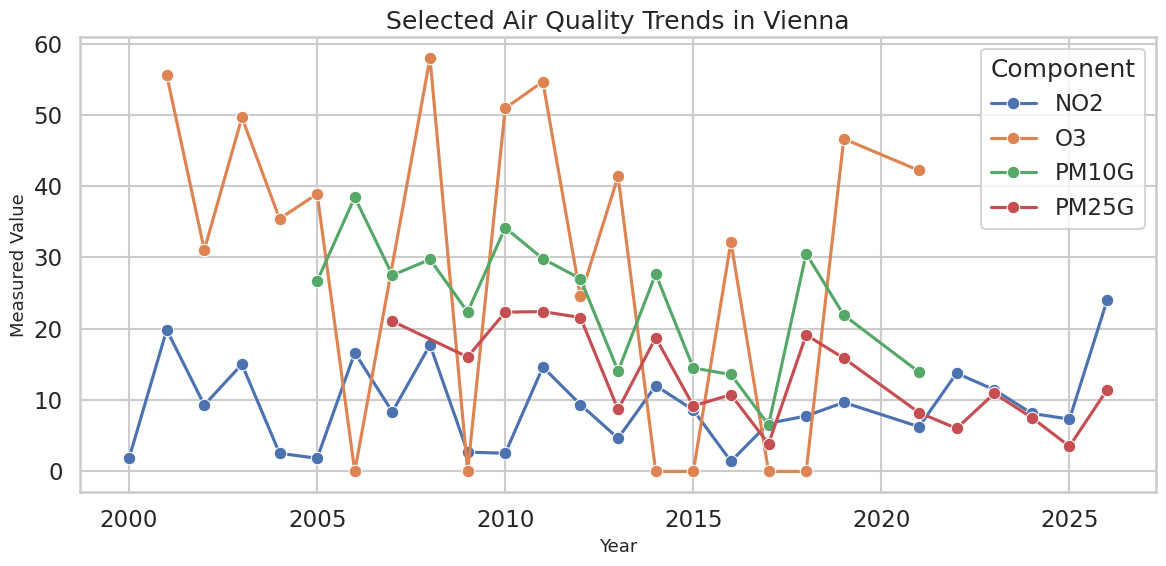

In [50]:
selected_components = ["NO2", "O3", "PM10G", "PM25G"]
available_components = [col for col in selected_components if col in air_quality_df.columns]
air_quality_long_df = air_quality_df[["Year"] + available_components].melt(
    id_vars="Year",
    var_name="component",
    value_name="value",
)
air_quality_long_df = air_quality_long_df.dropna(subset=["Year", "value"])

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=air_quality_long_df,
    x="Year",
    y="value",
    hue="component",
    marker="o",
)
plt.title("Selected Air Quality Trends in Vienna")
plt.xlabel("Year")
plt.ylabel("Measured Value")
plt.legend(title="Component")
plt.tight_layout()
plt.show()

## 6. PM2.5: Top 50 vs. Top 1000

PM2.5 ist fuer Ausdauersport plausibel, weil feinere Partikel die Atmung und damit die Belastung ueber die gesamte Renndauer beeinflussen koennen. Fuer die Praesentation ist hier besonders interessant, ob der Zusammenhang fuer die breitere schnelle Gruppe staerker ausfaellt als fuer die Elite.

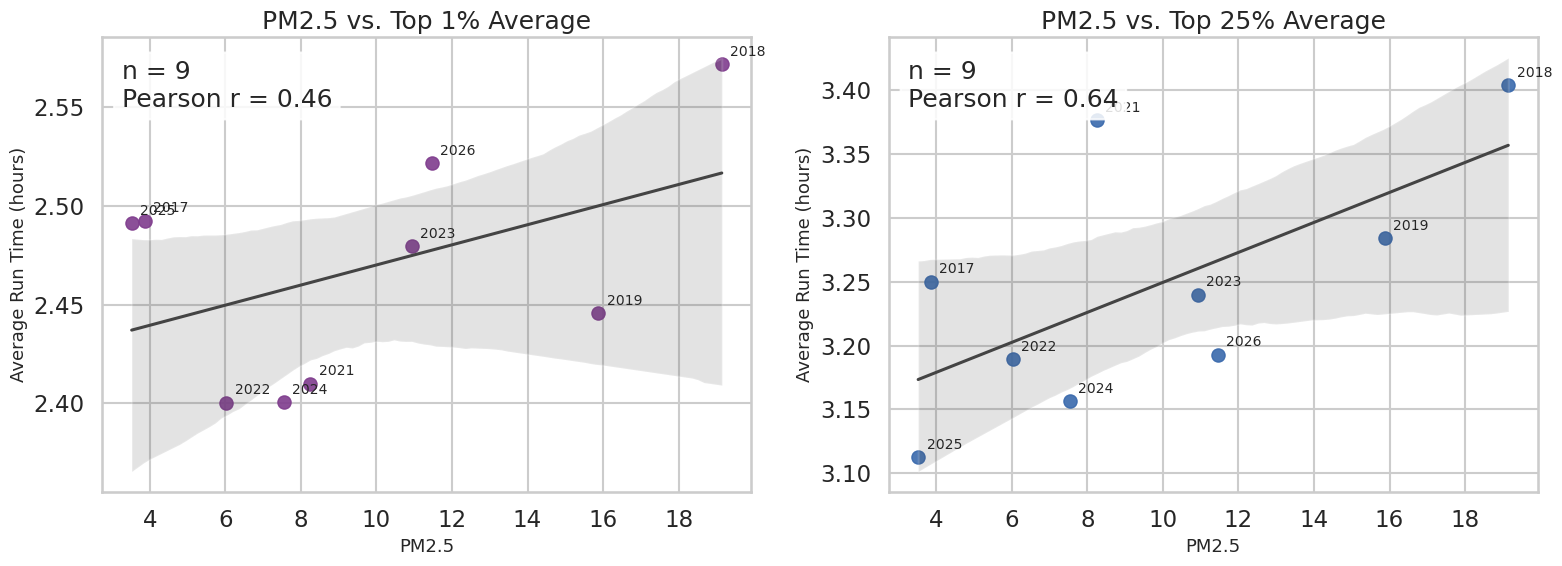

(   year       pm25  avg_top_1_percent_hours  avg_top_25_percent_hours
 0  2017   3.860000                 2.492588                  3.250160
 1  2018  19.144000                 2.571785                  3.403930
 2  2019  15.875500                 2.445858                  3.284016
 3  2021   8.245162                 2.409926                  3.376820
 4  2022   6.029162                 2.400388                  3.189625
 5  2023  10.931837                 2.479802                  3.239861
 6  2024   7.542422                 2.400439                  3.156449
 7  2025   3.518700                 2.491325                  3.112441
 8  2026  11.458521                 2.521730                  3.192894,
      group  observations  pearson_correlation
 0   Top 1%             9             0.456497
 1  Top 25%             9             0.640711,
                                             category  count  \
 0                                 used in PM2.5 plot      9   
 1  air-quality yea

In [88]:
air_performance_df = air_quality_df[["Year", "PM25G"]].copy()
air_performance_df = air_performance_df.rename(
    columns={"Year": "year", "PM25G": "pm25"}
)
air_performance_df = air_performance_df.dropna(subset=["year", "pm25"])

pm25_runtime_percentile_df = (
    runtime_percentile_df.assign(
        top_1_percent=runtime_percentile_df["rank_percent"] <= 1,
        top_25_percent=runtime_percentile_df["rank_percent"] <= 25,
    )
    .groupby("year")
    .agg(
        avg_top_1_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 1].mean()),
        avg_top_25_percent_hours=("run_hours", lambda values: values[runtime_percentile_df.loc[values.index, "rank_percent"] <= 25].mean()),
    )
    .reset_index()
)

air_performance_comparison_df = (
    air_performance_df.merge(pm25_runtime_percentile_df, on="year", how="inner")
    .sort_values("year")
)

marathon_runtime_years = set(pm25_runtime_percentile_df["year"].astype(int))
air_pm25_years = set(air_performance_df["year"].astype(int))
used_years = sorted(marathon_runtime_years & air_pm25_years)

air_year_coverage_df = pd.DataFrame(
    [
        {
            "category": "used in PM2.5 plot",
            "count": len(used_years),
            "years": ", ".join(map(str, used_years)),
        },
        {
            "category": "air-quality years with PM2.5 but no marathon runtime",
            "count": len(sorted(air_pm25_years - marathon_runtime_years)),
            "years": ", ".join(map(str, sorted(air_pm25_years - marathon_runtime_years))),
        },
        {
            "category": "marathon years missing PM2.5 data",
            "count": len(sorted(marathon_runtime_years - air_pm25_years)),
            "years": ", ".join(map(str, sorted(marathon_runtime_years - air_pm25_years))),
        },
    ]
)

pm25_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 1%",
            "observations": len(air_performance_comparison_df),
            "pearson_correlation": air_performance_comparison_df["pm25"].corr(
                air_performance_comparison_df["avg_top_1_percent_hours"]
            ),
        },
        {
            "group": "Top 25%",
            "observations": len(air_performance_comparison_df),
            "pearson_correlation": air_performance_comparison_df["pm25"].corr(
                air_performance_comparison_df["avg_top_25_percent_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_1_percent_hours", "Top 1%", "#7f3c8d"),
    (ax2, "avg_top_25_percent_hours", "Top 25%", "#3969ac"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=air_performance_comparison_df,
        x="pm25",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in air_performance_comparison_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["pm25"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = pm25_correlation_table.loc[
        pm25_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"PM2.5 vs. {label} Average")
    ax.set_xlabel("PM2.5")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(air_performance_comparison_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

air_performance_comparison_df, pm25_correlation_table, air_year_coverage_df

## 7. O3: Top 50 vs. Top 1000

Ozon wirkt anders als Feinstaub, kann aber die Atemwege unter Belastung ebenfalls reizen. Der direkte Links-rechts-Vergleich zeigt, ob auch hier die breitere Leistungsgruppe sensibler reagiert als die Spitzengruppe.

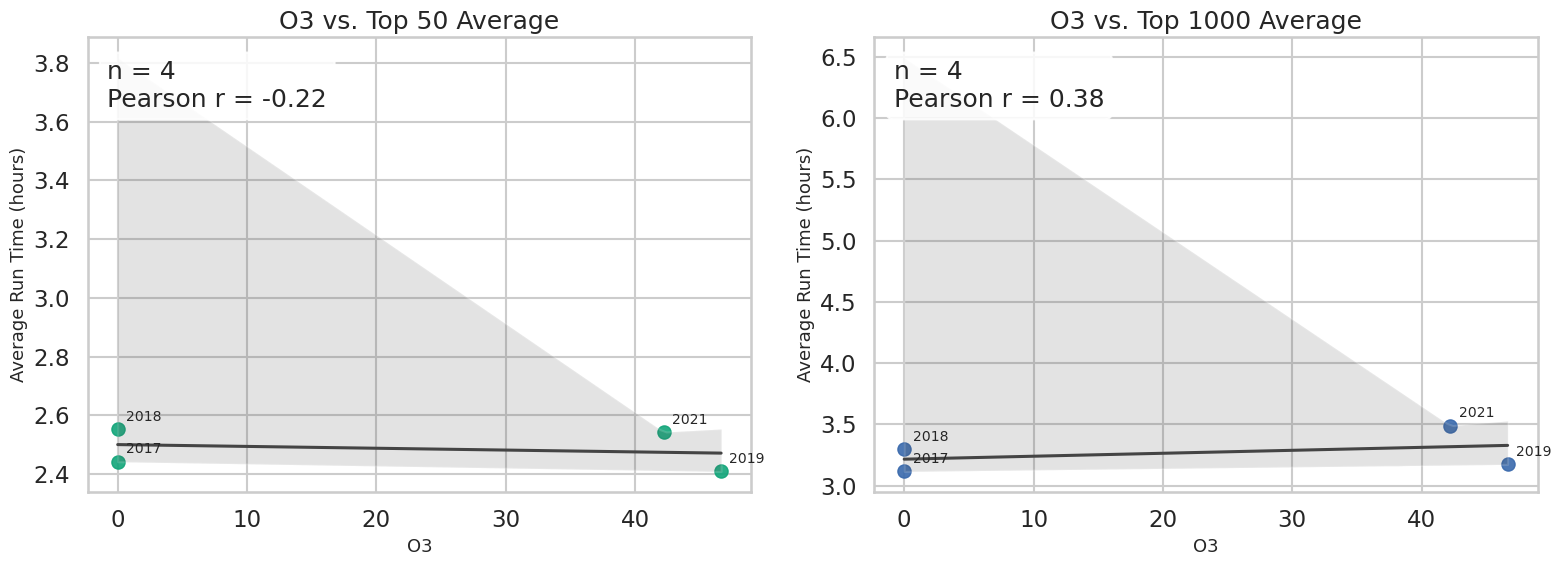

(   year         o3  avg_top_50_hours  avg_top_1000_hours
 0  2017   0.000000          2.442572            3.116924
 1  2018   0.000000          2.552578            3.300330
 2  2019  46.645400          2.409578            3.174321
 3  2021  42.207667          2.543383            3.489792,
       group  observations  pearson_correlation
 0    Top 50             4            -0.222936
 1  Top 1000             4             0.375502)

In [51]:
o3_performance_df = (
    air_performance_comparison_df[["year", "o3", "avg_top_50_hours", "avg_top_1000_hours"]]
    .dropna()
    .sort_values("year")
)

o3_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 50",
            "observations": len(o3_performance_df),
            "pearson_correlation": o3_performance_df["o3"].corr(
                o3_performance_df["avg_top_50_hours"]
            ),
        },
        {
            "group": "Top 1000",
            "observations": len(o3_performance_df),
            "pearson_correlation": o3_performance_df["o3"].corr(
                o3_performance_df["avg_top_1000_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_50_hours", "Top 50", "#11a579"),
    (ax2, "avg_top_1000_hours", "Top 1000", "#3969ac"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=o3_performance_df,
        x="o3",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in o3_performance_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["o3"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = o3_correlation_table.loc[
        o3_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"O3 vs. {label} Average")
    ax.set_xlabel("O3")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(o3_performance_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

o3_performance_df, o3_correlation_table

## 8. Niederschlag: Top 50 vs. Top 1000

Neben der Temperatur kann auch Niederschlag den Lauf beeinflussen, zum Beispiel ueber nasse Strecke, mehr Energieaufwand und unguenstigere Gesamtbedingungen. Fuer eure Aussage ist interessant, ob sich dieser Effekt beim breiteren schnellen Feld staerker zeigt als bei der Elite.

/home/dg/Programme/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dg/Programme/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


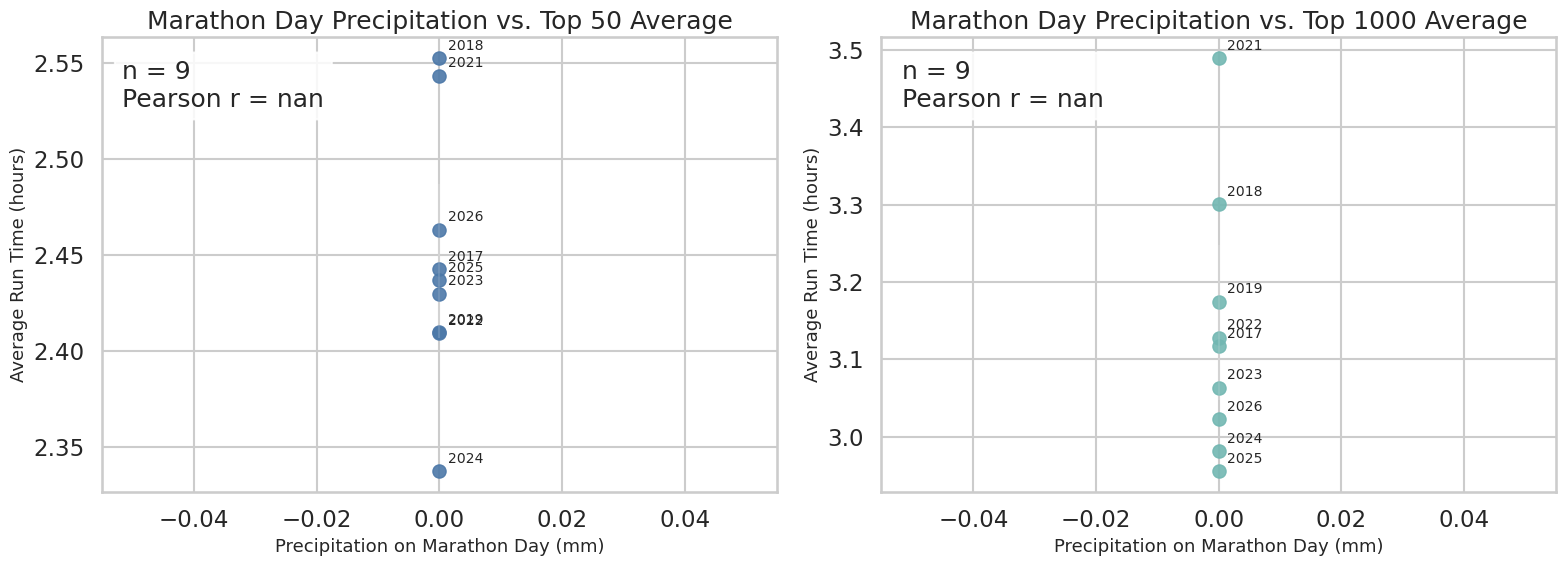

(   year  precipitation_mm  avg_top_50_hours  avg_top_1000_hours
 0  2017                 0          2.442572            3.116924
 1  2018                 0          2.552578            3.300330
 2  2019                 0          2.409578            3.174321
 3  2021                 0          2.543383            3.489792
 4  2022                 0          2.409267            3.127809
 5  2023                 0          2.429778            3.063252
 6  2024                 0          2.337167            2.981446
 7  2025                 0          2.436933            2.954827
 8  2026                 0          2.463056            3.022229,
       group  observations  pearson_correlation
 0    Top 50             9                  NaN
 1  Top 1000             9                  NaN)

In [52]:
precipitation_data_df = marathon_weather_df[["year", "precipitation_mm"]].copy()

performance_vs_precipitation_df = (
    precipitation_data_df.merge(top_n_average_df, on="year", how="inner")
    .sort_values("year")
)

precipitation_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 50",
            "observations": len(performance_vs_precipitation_df),
            "pearson_correlation": performance_vs_precipitation_df["precipitation_mm"].corr(
                performance_vs_precipitation_df["avg_top_50_hours"]
            ),
        },
        {
            "group": "Top 1000",
            "observations": len(performance_vs_precipitation_df),
            "pearson_correlation": performance_vs_precipitation_df["precipitation_mm"].corr(
                performance_vs_precipitation_df["avg_top_1000_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_50_hours", "Top 50", "#4c78a8"),
    (ax2, "avg_top_1000_hours", "Top 1000", "#72b7b2"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=performance_vs_precipitation_df,
        x="precipitation_mm",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in performance_vs_precipitation_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["precipitation_mm"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = precipitation_correlation_table.loc[
        precipitation_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"Marathon Day Precipitation vs. {label} Average")
    ax.set_xlabel("Precipitation on Marathon Day (mm)")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(performance_vs_precipitation_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

performance_vs_precipitation_df, precipitation_correlation_table

## 9. Windgeschwindigkeit am Marathon-Tag

Die Windgeschwindigkeit kann den Lauf erheblich beeinflussen, besonders bei Streckenabschnitten mit Seitenwind oder Gegenwind. Diese Grafik zeigt die Windverhältnisse an den jeweiligen Marathon-Tagen.

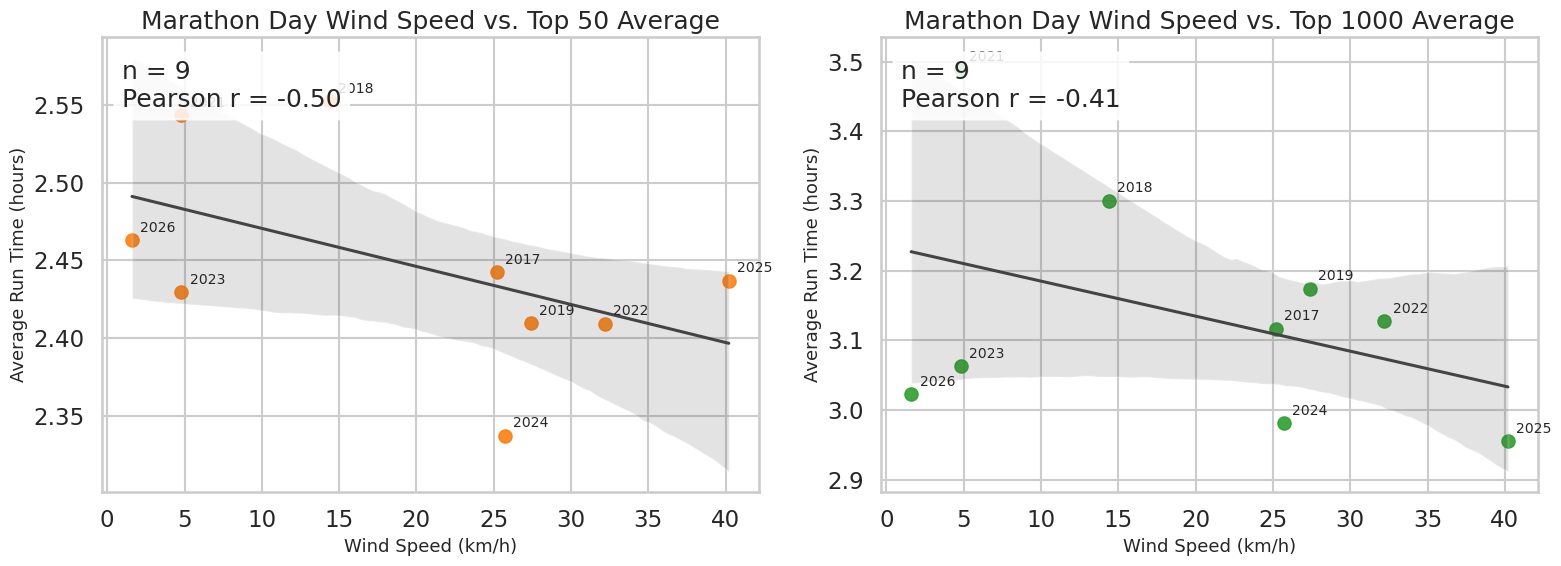

(   year  wind_kph  avg_top_50_hours  avg_top_1000_hours
 0  2017      25.2          2.442572            3.116924
 1  2018      14.4          2.552578            3.300330
 2  2019      27.4          2.409578            3.174321
 3  2021       4.8          2.543383            3.489792
 4  2022      32.2          2.409267            3.127809
 5  2023       4.8          2.429778            3.063252
 6  2024      25.7          2.337167            2.981446
 7  2025      40.2          2.436933            2.954827
 8  2026       1.6          2.463056            3.022229,
       group  observations  pearson_correlation
 0    Top 50             9            -0.500388
 1  Top 1000             9            -0.407241)

In [41]:
wind_data_df = marathon_weather_df[["year", "wind_kph"]].copy()

performance_vs_wind_df = (
    wind_data_df.merge(top_n_average_df, on="year", how="inner")
    .sort_values("year")
)

wind_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 50",
            "observations": len(performance_vs_wind_df),
            "pearson_correlation": performance_vs_wind_df["wind_kph"].corr(
                performance_vs_wind_df["avg_top_50_hours"]
            ),
        },
        {
            "group": "Top 1000",
            "observations": len(performance_vs_wind_df),
            "pearson_correlation": performance_vs_wind_df["wind_kph"].corr(
                performance_vs_wind_df["avg_top_1000_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_50_hours", "Top 50", "#ff7f0e"),
    (ax2, "avg_top_1000_hours", "Top 1000", "#2ca02c"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=performance_vs_wind_df,
        x="wind_kph",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in performance_vs_wind_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["wind_kph"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = wind_correlation_table.loc[
        wind_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"Marathon Day Wind Speed vs. {label} Average")
    ax.set_xlabel("Wind Speed (km/h)")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(performance_vs_wind_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

performance_vs_wind_df, wind_correlation_table

## 10. Luftfeuchtigkeit am Marathon-Tag

Die Luftfeuchtigkeit beeinflusst die Thermoregulation und die Leistung von Läufern erheblich. Höhere Luftfeuchtigkeit erschwert die Schweiß-Verdunstung, was zu höheren Belastungen führt.

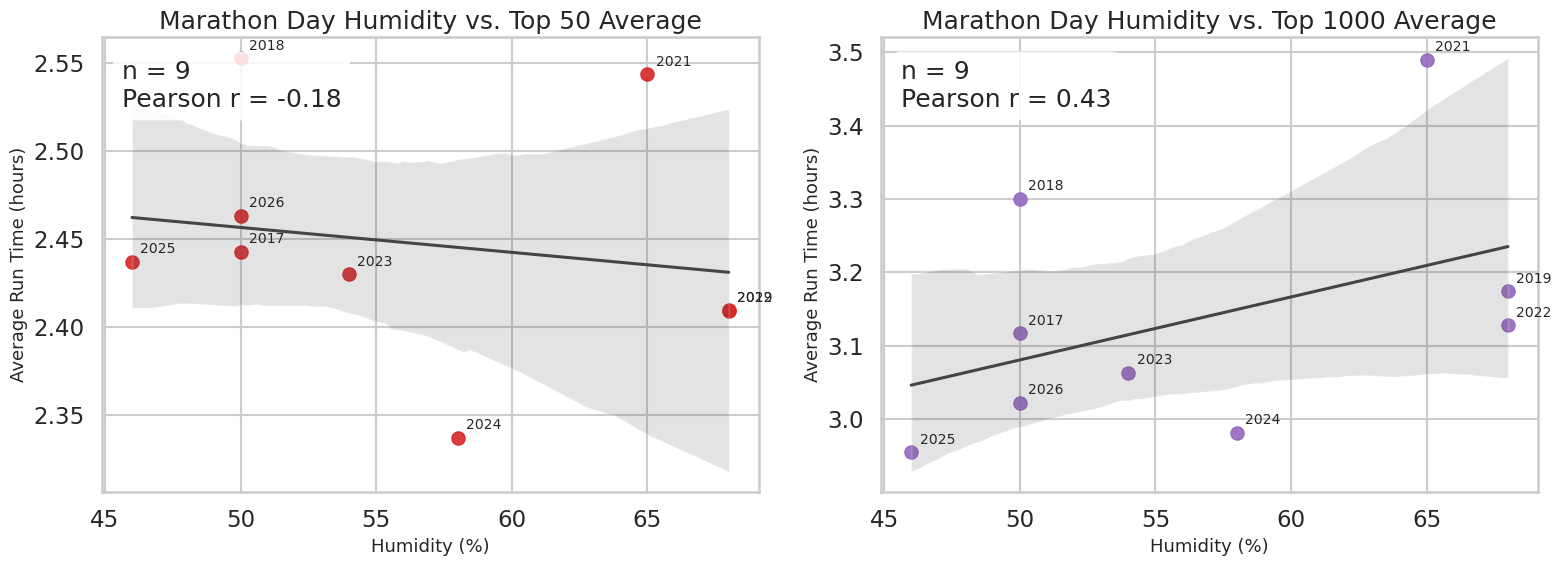

(   year  humidity  avg_top_50_hours  avg_top_1000_hours
 0  2017        50          2.442572            3.116924
 1  2018        50          2.552578            3.300330
 2  2019        68          2.409578            3.174321
 3  2021        65          2.543383            3.489792
 4  2022        68          2.409267            3.127809
 5  2023        54          2.429778            3.063252
 6  2024        58          2.337167            2.981446
 7  2025        46          2.436933            2.954827
 8  2026        50          2.463056            3.022229,
       group  observations  pearson_correlation
 0    Top 50             9            -0.179752
 1  Top 1000             9             0.433098)

In [42]:
humidity_data_df = marathon_weather_df[["year", "humidity"]].copy()

performance_vs_humidity_df = (
    humidity_data_df.merge(top_n_average_df, on="year", how="inner")
    .sort_values("year")
)

humidity_correlation_table = pd.DataFrame(
    [
        {
            "group": "Top 50",
            "observations": len(performance_vs_humidity_df),
            "pearson_correlation": performance_vs_humidity_df["humidity"].corr(
                performance_vs_humidity_df["avg_top_50_hours"]
            ),
        },
        {
            "group": "Top 1000",
            "observations": len(performance_vs_humidity_df),
            "pearson_correlation": performance_vs_humidity_df["humidity"].corr(
                performance_vs_humidity_df["avg_top_1000_hours"]
            ),
        },
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

comparison_specs = [
    (ax1, "avg_top_50_hours", "Top 50", "#d62728"),
    (ax2, "avg_top_1000_hours", "Top 1000", "#9467bd"),
]

for ax, metric, label, color in comparison_specs:
    sns.regplot(
        data=performance_vs_humidity_df,
        x="humidity",
        y=metric,
        scatter_kws={"s": 90, "color": color, "alpha": 0.9},
        line_kws={"color": "#444444", "linewidth": 2.2},
        ax=ax,
    )

    for _, row in performance_vs_humidity_df.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["humidity"], row[metric]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )

    correlation_value = humidity_correlation_table.loc[
        humidity_correlation_table["group"] == label,
        "pearson_correlation",
    ].iloc[0]

    ax.set_title(f"Marathon Day Humidity vs. {label} Average")
    ax.set_xlabel("Humidity (%)")
    ax.set_ylabel("Average Run Time (hours)")
    ax.text(
        0.03,
        0.95,
        f"n = {len(performance_vs_humidity_df)}\nPearson r = {correlation_value:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

plt.tight_layout()
plt.show()

performance_vs_humidity_df, humidity_correlation_table

## 11. Elite-Analyse: Performance-Trends nach Kategorie

Diese Analyse konzentriert sich auf die Top-10-Läufer in verschiedenen Kategorien (Geschlecht und Altersgruppen). Die Performance-Trends zeigen, wie sich die Spitzengruppen über die Jahre entwickelt haben.


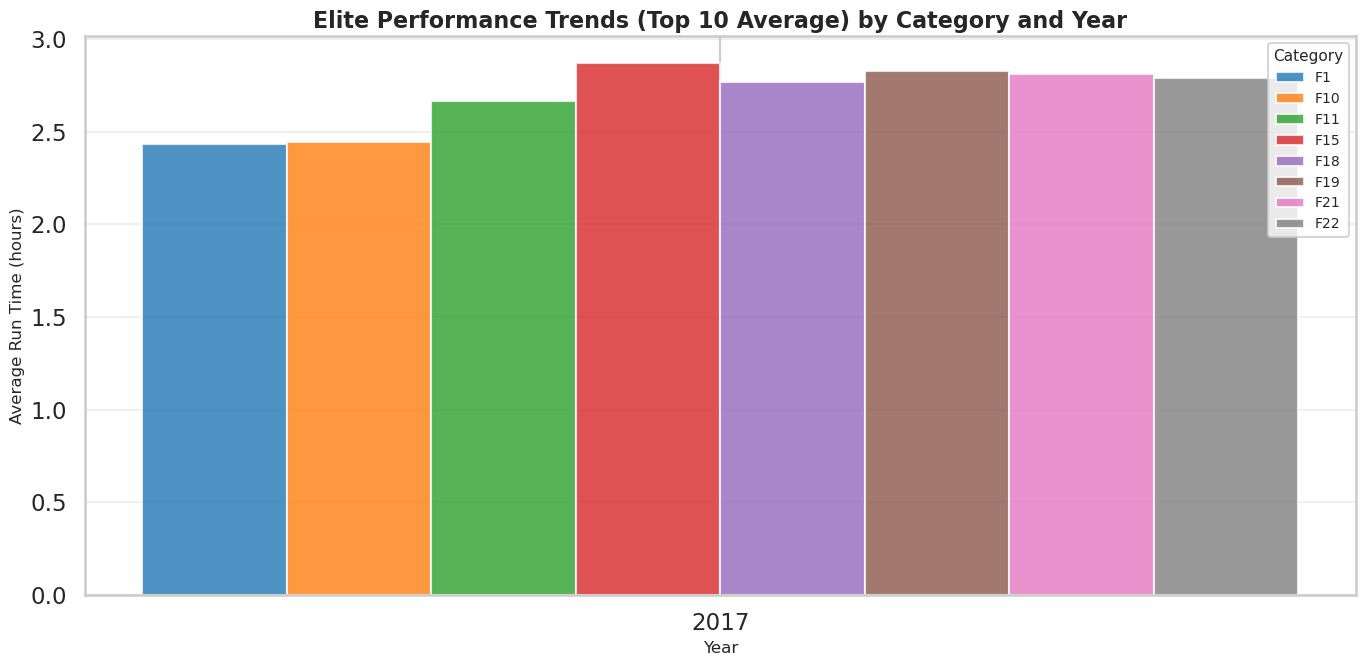

Major Categories analyzed: ['F1', 'F10', 'F11', 'F15', 'F18', 'F19', 'F21', 'F22']


,year,category,elite_avg_hours
0,2017,F1,2.435000
1,2017,F10,2.441944
2,2017,F11,2.662778
3,2017,F15,2.870556
4,2017,F18,2.767500
5,2017,F19,2.826111
6,2017,F21,2.813333
7,2017,F22,2.789722


In [59]:
# Kategorie aus bib_number extrahieren
marathon_df_with_category = marathon_df.copy()
marathon_df_with_category["category"] = marathon_df_with_category["bib_number"].str.extract(r"([MF]\d+)", expand=False)
marathon_df_with_category = marathon_df_with_category.dropna(subset=["category"])

# Top 10 pro Kategorie pro Jahr ermitteln
elite_by_category = (
    marathon_df_with_category
    .sort_values(["year", "category", "run_hours"])
    .groupby(["year", "category"])
    .head(10)
    .reset_index(drop=True)
)

# Durchschnittliche Elite-Zeit pro Kategorie pro Jahr
elite_avg_by_category = (
    elite_by_category
    .groupby(["year", "category"])
    .agg({"run_hours": "mean"})
    .reset_index()
    .rename(columns={"run_hours": "elite_avg_hours"})
)

# Die wichtigsten Kategorien (mindestens 5 Jahre mit Daten)
major_categories = (
    elite_avg_by_category
    .groupby("category")
    .size()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

elite_major = elite_avg_by_category[elite_avg_by_category["category"].isin(major_categories)]

# Plot: Gruppiertes Balkendiagramm pro Jahr und Kategorie
fig, ax = plt.subplots(figsize=(14, 7))

years = sorted(elite_major["year"].unique())
x = np.arange(len(years))
width = 0.11  # Breite der Balken

colors = plt.cm.tab10(range(len(major_categories)))

for idx, category in enumerate(major_categories):
    cat_data = elite_major[elite_major["category"] == category].sort_values("year")
    times = [cat_data[cat_data["year"] == year]["elite_avg_hours"].values[0] if year in cat_data["year"].values else np.nan for year in years]
    
    offset = width * (idx - len(major_categories) / 2 + 0.5)
    ax.bar(x + offset, times, width, label=category, color=colors[idx], alpha=0.8)

ax.set_title("Elite Performance Trends (Top 10 Average) by Category and Year", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average Run Time (hours)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend(title="Category", fontsize=10, title_fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Major Categories analyzed: {major_categories}")
elite_major.head(20)

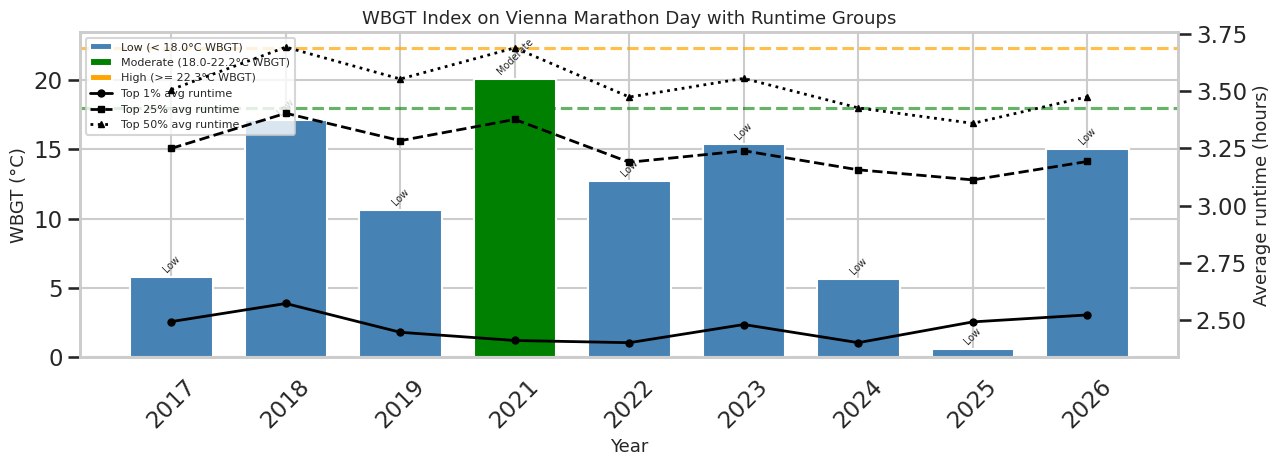

,year,wbgt,risk,avg_top_1_percent_hours,avg_top_25_percent_hours,avg_top_50_percent_hours
0,2017,5.786228,Low,2.492588,3.250160,3.507314
1,2018,17.086592,Low,2.571785,3.403930,3.693213
2,2019,10.585406,Low,2.445858,3.284016,3.553625
3,2021,20.059292,Moderate,2.409926,3.376820,3.690148
4,2022,12.708413,Low,2.400388,3.189625,3.474831
5,2023,15.376433,Low,2.479802,3.239861,3.556408
6,2024,5.617389,Low,2.400439,3.156449,3.427223
7,2025,0.585681,Low,2.491325,3.112441,3.359740
8,2026,14.994323,Low,2.521730,3.192894,3.475985


In [89]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "CSV").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

WEATHER_PATH = PROJECT_ROOT / "CSV" / "weather.csv"
MARATHON_PATH = PROJECT_ROOT / "CSV" / "vienna_city_marathon_all_years_participants.csv"

wbgt_weather_df = pd.read_csv(WEATHER_PATH)


def wet_bulb(T, rh):
    return (T * np.arctan(0.151977 * (rh + 8.313659) ** 0.5)
            + np.arctan(T + rh)
            - np.arctan(rh - 1.676331)
            + 0.00391838 * rh ** 1.5 * np.arctan(0.023101 * rh)
            - 4.686035)


wbgt_weather_df["wet_bulb"] = wet_bulb(wbgt_weather_df["temp_c"], wbgt_weather_df["humidity"])
wbgt_weather_df["wbgt"] = 0.7 * wbgt_weather_df["wet_bulb"] + 0.3 * wbgt_weather_df["temp_c"]


def wbgt_risk(w):
    if w < 18.0:
        return "Low"
    elif w < 22.3:
        return "Moderate"
    else:
        return "High"


wbgt_weather_df["risk"] = wbgt_weather_df["wbgt"].apply(wbgt_risk)

color_map = {
    "Low": "steelblue",
    "Moderate": "green",
    "High": "orange",
}

marathon_df_full = pd.read_csv(MARATHON_PATH)
marathon_df_full["run_duration"] = pd.to_timedelta(marathon_df_full["run_time"], errors="coerce")
marathon_df_full["run_hours"] = marathon_df_full["run_duration"].dt.total_seconds() / 3600
marathon_df_full = marathon_df_full.dropna(subset=["year", "run_hours"]).copy()

runtime_rank_df = marathon_df_full[["year", "run_hours"]].copy()
runtime_rank_df = runtime_rank_df.sort_values(["year", "run_hours"]).reset_index(drop=True)
runtime_rank_df["rank_in_year"] = runtime_rank_df.groupby("year").cumcount() + 1
runtime_rank_df["participants_in_year"] = runtime_rank_df.groupby("year")["rank_in_year"].transform("max")
runtime_rank_df["rank_percent"] = (
    runtime_rank_df["rank_in_year"]
    / runtime_rank_df["participants_in_year"]
    * 100
)

runtime_percentile_avg = (
    runtime_rank_df.groupby("year")
    .agg(
        avg_top_1_percent_hours=("run_hours", lambda values: values[runtime_rank_df.loc[values.index, "rank_percent"] <= 1].mean()),
        avg_top_25_percent_hours=("run_hours", lambda values: values[runtime_rank_df.loc[values.index, "rank_percent"] <= 25].mean()),
        avg_top_50_percent_hours=("run_hours", lambda values: values[runtime_rank_df.loc[values.index, "rank_percent"] <= 50].mean()),
    )
    .reset_index()
)

wbgt_performance_df = (
    wbgt_weather_df.merge(runtime_percentile_avg, on="year", how="inner")
    .sort_values("year")
)

x_positions = np.arange(len(wbgt_performance_df))
year_labels = wbgt_performance_df["year"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    x_positions,
    wbgt_performance_df["wbgt"],
    color=wbgt_performance_df["risk"].map(color_map),
    edgecolor="white",
    width=0.72,
    zorder=2,
)

ax.axhline(18.0, linestyle="--", color="green", alpha=0.6)
ax.axhline(22.3, linestyle="--", color="orange", alpha=0.7)

for bar, risk in zip(bars, wbgt_performance_df["risk"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        risk,
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=45,
    )

ax2 = ax.twinx()
line_specs = [
    ("avg_top_1_percent_hours", "Top 1% avg runtime", "o", "-"),
    ("avg_top_25_percent_hours", "Top 25% avg runtime", "s", "--"),
    ("avg_top_50_percent_hours", "Top 50% avg runtime", "^", ":"),
]

for metric, label, marker, linestyle in line_specs:
    ax2.plot(
        x_positions,
        wbgt_performance_df[metric],
        color="black",
        marker=marker,
        linestyle=linestyle,
        linewidth=2,
        markersize=5,
        label=label,
        zorder=4,
    )

ax2.set_ylabel("Average runtime (hours)")
ax2.grid(False)

legend_elements = [
    Patch(facecolor="steelblue", label="Low (< 18.0°C WBGT)"),
    Patch(facecolor="green", label="Moderate (18.0-22.2°C WBGT)"),
    Patch(facecolor="orange", label="High (>= 22.3°C WBGT)"),
]
runtime_handles, runtime_labels = ax2.get_legend_handles_labels()
ax.legend(legend_elements + runtime_handles, [item.get_label() for item in legend_elements] + runtime_labels, fontsize=8, loc="upper left")

ax.set_title("WBGT Index on Vienna Marathon Day with Runtime Groups", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("WBGT (°C)")
ax.set_xticks(x_positions)
ax.set_xticklabels(year_labels, rotation=45)

plt.tight_layout()
plt.savefig("weather_wbgt_performance_overlay.png", dpi=150)
plt.show()

wbgt_performance_df[["year", "wbgt", "risk", "avg_top_1_percent_hours", "avg_top_25_percent_hours", "avg_top_50_percent_hours"]]

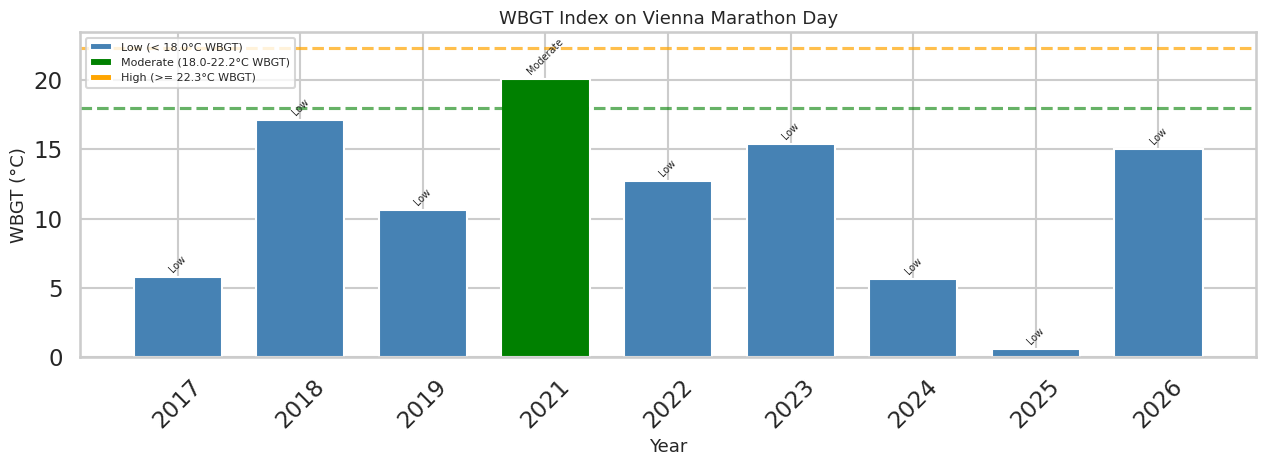

,year,wbgt,risk
0,2017,5.786228,Low
1,2018,17.086592,Low
2,2019,10.585406,Low
3,2021,20.059292,Moderate
4,2022,12.708413,Low
5,2023,15.376433,Low
6,2024,5.617389,Low
7,2025,0.585681,Low
8,2026,14.994323,Low


In [90]:
wbgt_only_df = wbgt_performance_df.copy()

x_positions = np.arange(len(wbgt_only_df))
year_labels = wbgt_only_df["year"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    x_positions,
    wbgt_only_df["wbgt"],
    color=wbgt_only_df["risk"].map(color_map),
    edgecolor="white",
    width=0.72,
    zorder=2,
)

ax.axhline(18.0, linestyle="--", color="green", alpha=0.6)
ax.axhline(22.3, linestyle="--", color="orange", alpha=0.7)

for bar, risk in zip(bars, wbgt_only_df["risk"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        risk,
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=45,
    )

legend_elements = [
    Patch(facecolor="steelblue", label="Low (< 18.0°C WBGT)"),
    Patch(facecolor="green", label="Moderate (18.0-22.2°C WBGT)"),
    Patch(facecolor="orange", label="High (>= 22.3°C WBGT)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper left")

ax.set_title("WBGT Index on Vienna Marathon Day", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("WBGT (°C)")
ax.set_xticks(x_positions)
ax.set_xticklabels(year_labels, rotation=45)

plt.tight_layout()
plt.savefig("weather_wbgt_without_runtimes.png", dpi=150)
plt.show()

wbgt_only_df[["year", "wbgt", "risk"]]